# BEAD Random Forest Model
Predicts `funding_per_location` (raw $, no log transform) using 8 features from the BEAD Summary Paper.

# Setup

In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

import shutil
HAS_LATEX = shutil.which('pdflatex') is not None

plt.rcParams.update({
    'text.usetex': HAS_LATEX,       # True when pdflatex available, renders Computer Modern
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'font.size': 9,
    'mathtext.fontset': 'cm',
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

if not HAS_LATEX:
    print('Note: pdflatex not found — using mathtext fallback. '
          'Install TeX Live for full LaTeX rendering.')

client = bigquery.Client(project='broadband-data')
print(f'Ready (LaTeX: {HAS_LATEX})')

/opt/homebrew/Caskroom/miniconda/base/envs/irt-bead/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ready (LaTeX: True)


In [2]:
cai_query = """
SELECT
    location_id,
    project_id

FROM `broadband-data.fp_approved.cai`
"""

loc_query = """
SELECT
    location_id,
    project_id

FROM `broadband-data.fp_approved.locations`
"""
df_loc = client.query(loc_query).to_dataframe()
df_cai = client.query(cai_query).to_dataframe()

In [3]:
df_loc.dropna()
df_cai.dropna()
df_all = pd.concat([df_loc, df_cai])

In [4]:
proj = """
SELECT
    DISTINCT project_id

FROM `broadband-data.fp_approved.deployment_projects`
"""

proj = client.query(proj).to_dataframe()

In [5]:
# Identify IDs in df_all that do not exist in proj.project_id
missing_ids = df_all.loc[~df_all['project_id'].isin(proj.project_id), 'project_id'].unique()

# Print the results
if len(missing_ids) > 0:
    print(f"Project IDs in DataFrame but missing from proj: {list(missing_ids)}")
else:
    print("All DataFrame project IDs exist in proj!")

Project IDs in DataFrame but missing from proj: ['CM61-BEAD-GA-002022', 'CM61-BEAD-GA-002023', 'CM61-BEAD-GA-002024', 'CM61-BEAD-GA-002026']


In [6]:
len(set(df_all['project_id']))

5255

# Data Creation

In [7]:
# aggregate fp_approved.locations with competition data
location_query = """
SELECT
    comp.*,

    -- project-level fields repeated per location
    proj.bead_support AS funding_total,
    proj.project_type,
    proj.estimated_jobs,
    proj.estimated_miles_aerial_fiber + proj.estimated_miles_buried_fiber AS total_miles,

    -- count locations per project via window function
    COUNT(*) OVER (PARTITION BY comp.project_id) AS project_total_locations,

    -- normalized per-location metrics
    proj.bead_support / COUNT(*) OVER (PARTITION BY comp.project_id) AS funding_per_location,
    proj.estimated_jobs 
        / COUNT(*) OVER (PARTITION BY comp.project_id) AS jobs_per_location,
    (proj.estimated_miles_aerial_fiber + proj.estimated_miles_buried_fiber) 
        / COUNT(*) OVER (PARTITION BY comp.project_id) AS miles_per_location

FROM `broadband-data.fp_approved.competition_analysis` comp
JOIN `broadband-data.fp_approved.deployment_projects` proj 
    ON comp.project_id = proj.project_id
"""
df_loc_comp = client.query(location_query).to_dataframe()
print(f"Location aggregates: {df_loc_comp.shape}")
df_loc_comp.head()

Location aggregates: (3379655, 37)


,location_id,state,awarded_technology,project_id,provider_id,provider_match_method,present_at_location,present_at_location_qualifying,present_same_tech,present_same_tech_qualifying,...,tech_coverage,tech_served_coverage,funding_total,project_type,estimated_jobs,total_miles,project_total_locations,funding_per_location,jobs_per_location,miles_per_location
0,1078346321,MO,50,CM61-BEAD-004088,470022,provider_id,False,False,False,False,...,NaN,NaN,845408.0,L,5.0,42.0,268,3154.507463,0.018657,0.156716
1,1078345693,MO,50,CM61-BEAD-004088,470022,provider_id,False,False,False,False,...,NaN,NaN,845408.0,L,5.0,42.0,268,3154.507463,0.018657,0.156716
2,1078345753,MO,50,CM61-BEAD-004088,470022,provider_id,False,False,False,False,...,NaN,NaN,845408.0,L,5.0,42.0,268,3154.507463,0.018657,0.156716
3,1078345819,MO,50,CM61-BEAD-004088,470022,provider_id,True,False,False,False,...,NaN,NaN,845408.0,L,5.0,42.0,268,3154.507463,0.018657,0.156716
4,1078346280,MO,50,CM61-BEAD-004088,470022,provider_id,False,False,False,False,...,NaN,NaN,845408.0,L,5.0,42.0,268,3154.507463,0.018657,0.156716


In [8]:
# Aggregate fp_approved.locations to project level
nbm_join_query = """
SELECT DISTINCT
    loc.location_id,
    nbm.block_geoid
FROM `broadband-data.fp_approved.locations` loc
JOIN `broadband-data.fcc_bdc.nbm_hive` nbm
  ON loc.location_id = nbm.location_id
WHERE nbm.period = '2025_06'
"""
df_nbm = client.query(nbm_join_query).to_dataframe()
print(f"Location aggregates: {df_nbm.shape}")
df_nbm.head()

Location aggregates: (3302309, 2)


,location_id,block_geoid
0,1051701824,021700011003000
1,1051729728,021700002001019
2,1046992795,020900009003008
3,1374761902,021220003001160
4,1051750889,021700004021045


In [9]:
# # household count by county (2025)
# skipping since we are using 2020 data for all
# hh_count_query = """
# SELECT 
#     STNAME AS state,
#     COUNTY_CODE AS county_id,
#     hh_2025 AS household_count
# FROM `broadband-data.census_data.household_county_2020_2025`
# """
# df_hh_count = client.query(hh_count_query).to_dataframe()
# print(f"Household count data: {df_hh_count.shape}")
# print(df_hh_count.sort_values('household_count', ascending=False).head(10))

In [10]:
# 1. county-level information
# source: https://www.census.gov/programs-surveys/geography/guidance/geo-areas/urban-rural.html
df_county_info = pd.read_excel('../2020_UA_COUNTY.xlsx')

In [11]:
df_county_info['STATE'] = df_county_info['STATE'].astype(str).str.zfill(2)
df_county_info['COUNTY'] = df_county_info['COUNTY'].astype(str).str.zfill(3)
df_county_info['county_id'] = df_county_info['STATE'] + df_county_info['COUNTY']

In [12]:
# 2. remoteness data
# source: https://www.ers.usda.gov/data-products/rural-urban-continuum-codes
df_remoteness = pd.read_csv('../Ruralurbancontinuumcodes2023.csv', encoding='ISO-8859-1')

In [13]:
# pivot from long to wide
df_rucc_wide = df_remoteness.pivot_table(
    index=["FIPS", "State", "County_Name"],
    columns="Attribute",
    values="Value",
    aggfunc="first"
).reset_index()

# flatten the column MultiIndex
df_rucc_wide.columns.name = None

# pad county_id to 5 digits
df_rucc_wide["county_id"] = df_rucc_wide["FIPS"].astype(str).str.zfill(5)

# cast numeric columns (pivot makes everything object/string)
df_rucc_wide["Population_2020"] = pd.to_numeric(df_rucc_wide["Population_2020"], errors="coerce")
df_rucc_wide["RUCC_2023"] = pd.to_numeric(df_rucc_wide["RUCC_2023"], errors="coerce")

# verify
print(df_rucc_wide.dtypes)
print(f"\nFIPS examples: {df_rucc_wide['county_id'].head().tolist()}")
print(f"Any 4-digit FIPS remaining: {(df_rucc_wide['county_id'].str.len() < 5).sum()}")
df_rucc_wide.head()

FIPS                 int64
State               object
County_Name         object
Description         object
Population_2020      int64
RUCC_2023          float64
county_id           object
dtype: object

FIPS examples: ['01001', '01003', '01005', '01007', '01009']
Any 4-digit FIPS remaining: 0


,FIPS,State,County_Name,Description,Population_2020,RUCC_2023,county_id
0,1001,AL,Autauga County,"Metro - Counties in metro areas of 250,000 to ...",58805,2.0,01001
1,1003,AL,Baldwin County,Metro - Counties in metro areas of fewer than ...,231767,3.0,01003
2,1005,AL,Barbour County,"Nonmetro - Urban population of 5,000 to 20,000...",25223,6.0,01005
3,1007,AL,Bibb County,Metro - Counties in metro areas of 1 million p...,22293,1.0,01007
4,1009,AL,Blount County,Metro - Counties in metro areas of 1 million p...,59134,1.0,01009


In [14]:
# 3. poverty via ACS 5-Year Estimates (county level)
# source: https://data.census.gov/table/ACSDT5Y2022.B17001
# B17001_001E = total population for poverty status determination
# B17001_002E = population below poverty level

df_poverty = pd.read_csv('../ACSDT5Y2024.B17001_2026-07-15T133739/ACSDT5Y2024.B17001-Data.csv')
df_poverty = df_poverty.iloc[1:]
df_poverty['county_id'] = df_poverty['GEO_ID'].str[-5:]
df_poverty.head()

,GEO_ID,NAME,B17001_001E,B17001_001M,B17001_002E,B17001_002M,B17001_003E,B17001_003M,B17001_004E,B17001_004M,...,B17001_056E,B17001_056M,B17001_057E,B17001_057M,B17001_058E,B17001_058M,B17001_059E,B17001_059M,Unnamed: 120,county_id
1,0500000US01001,"Autauga County, Alabama",59480,79,6715,1269,3033,669,286,149,...,3570,276,3453,220,2747,119,2203,116,NaN,01001
2,0500000US01003,"Baldwin County, Alabama",243473,332,24573,2537,10383,1323,1230,270,...,14762,441,16118,615,15555,270,10186,346,NaN,01003
3,0500000US01005,"Barbour County, Alabama",21583,80,4615,693,1893,334,265,78,...,1025,111,1267,134,1302,77,1011,102,NaN,01005
4,0500000US01007,"Bibb County, Alabama",20488,260,4601,693,2104,428,193,144,...,1071,105,1042,163,965,103,846,93,NaN,01007
5,0500000US01009,"Blount County, Alabama",58872,114,7571,907,3410,568,344,111,...,3395,175,3430,212,3118,177,1909,240,NaN,01009


In [15]:
# 4. topography data
# caveat: last updated in 1999
# source: https://www.ers.usda.gov/data-products/natural-amenities-scale
df_topo = pd.read_excel('../natamenf.xls')

In [16]:
df_topo = df_topo.iloc[103:]
df_topo.columns = df_topo.iloc[0]
df_topo = df_topo[1:]
df_topo = df_topo.reset_index(drop=True)
df_topo['county_id'] = df_topo['FIPS Code'].astype(str).str.zfill(5)

In [17]:
df_topo = df_topo.rename(columns={
    'topography code': 'topography_raw',
    'TOPOG - Z': 'topography_z',
    'Water area * 100': 'water_area_pct',
})

In [18]:
df_topo

103,FIPS Code,for measures,STATE,County name,Division,1993,1993,"January, 1941-70","January, 1941-70","July, 1941-70",...,water_area_pct,JAN TEMP - Z,JAN SUN - Z,JUL TEMP - Z,JUL HUM - Z,topography_z,LN WATER AREA - Z,Scale,1=Low 7=High,county_id
0,01001,01001,AL,AUTAUGA,6,2,2,47.4,130,81,...,4.944,1.20277,-0.64758,-0.13206,-0.68502,0.77701,0.26585,0.78,4,01001
1,01003,01003,AL,BALDWIN,6,2,2,51.9,152,80.6,...,7.661,1.57504,0.01482,0.36308,-1.09576,-0.73966,1.70428,1.82,4,01003
2,01005,01005,AL,BARBOUR,6,6,5,48.8,152,81,...,5.378,1.31859,0.01482,-0.01148,-0.89039,-0.73966,0.4957,0.19,4,01005
3,01007,01007,AL,BIBB,6,6,6,44.8,130,80.8,...,3.916,0.98768,-0.64758,-0.30223,-0.68502,0.77701,-0.27812,-0.15,3,01007
4,01009,01009,AL,BLOUNT,6,2,2,41.9,130,78.4,...,4.336,0.74778,-0.64758,0.0933,-0.68502,0.77701,-0.05592,0.23,4,01009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3106,56037,56037,WY,SWEETWATER,8,5,7,19.2,169,68.2,...,4.14,-1.13009,0.52667,0.8807,2.19018,0.32201,-0.15981,2.63,5,56037
3107,56039,56039,WY,TETON,8,7,8,11.4,137,58.2,...,6.228,-1.77535,-0.43682,2.89768,1.91635,1.83868,0.94589,5.39,6,56039
3108,56041,56041,WY,UINTA,8,7,7,17.9,169,62.7,...,3.343,-1.23763,0.52667,2.24757,2.19018,0.17034,-0.58134,3.32,5,56041
3109,56043,56043,WY,WASHAKIE,8,7,8,15.3,167,71.5,...,2.484,-1.45272,0.46645,-0.34251,1.77944,1.68702,-1.03595,1.1,4,56043


In [19]:
# ruggedness data https://www.ers.usda.gov/data-products/area-and-road-ruggedness-scales
df_rugged = pd.read_csv('../ruggedness-scales-2020-tracts.csv', encoding='ISO-8859-1')

In [20]:
df_rugged['county_id'] = df_rugged['CountyFIPS23'].astype(str).str.zfill(5)

In [21]:
df_rugged_county = df_rugged.groupby('county_id').agg({'RRS': 'mean', 'ARS': 'mean'}).reset_index()

In [22]:
df_rugged_county

,county_id,RRS,ARS
0,01001,1.352941,1.588235
1,01003,1.093023,1.046512
2,01005,1.111111,1.777778
3,01007,1.750000,1.875000
4,01009,2.125000,2.312500
...,...,...,...
3139,56037,1.692308,2.076923
3140,56039,3.285714,4.285714
3141,56041,1.833333,2.000000
3142,56043,1.333333,1.333333


In [23]:
df_nbm['county_id'] = df_nbm['block_geoid'].str[:5]

In [24]:
df_loc_comp_cp = df_loc_comp.copy()

# EDA

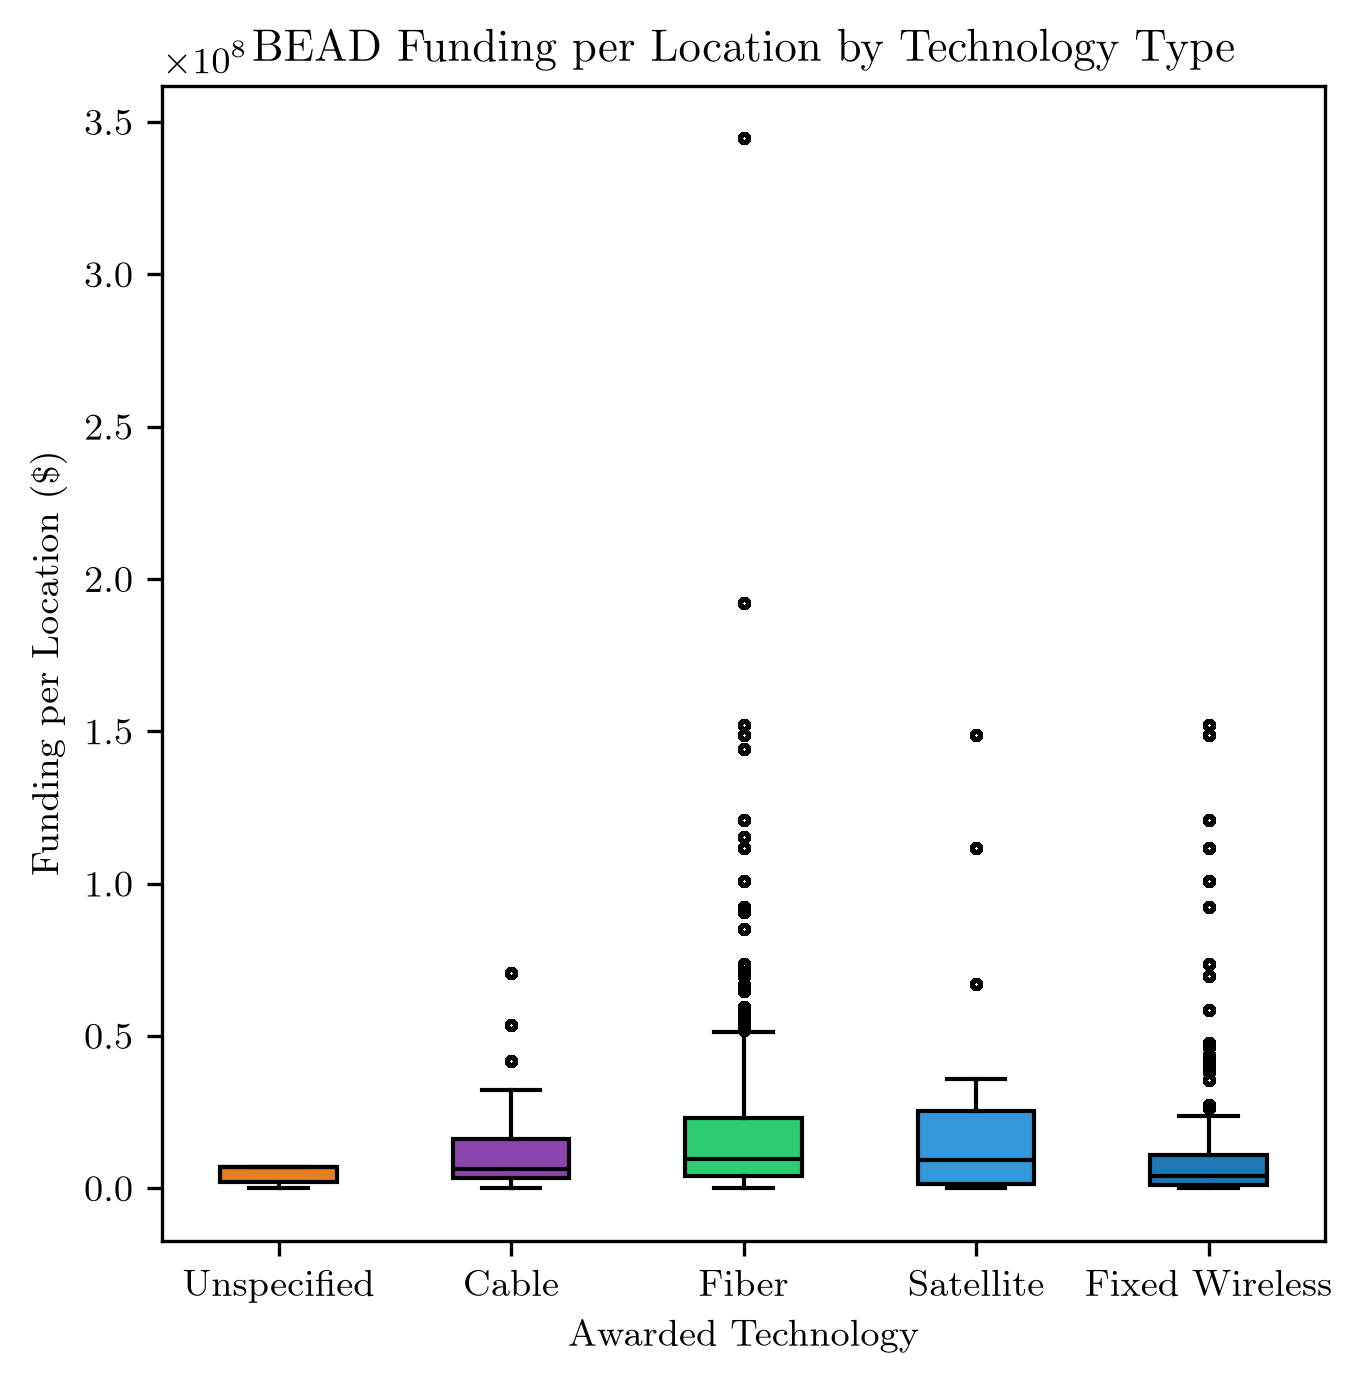

In [25]:
# remap before one-hot encoding
tech_map = {
    60: 61,
    70: 71,   # group all as fw
    72: 71,   # group all as fw
}
df_loc_comp_cp['awarded_technology'] = df_loc_comp_cp['awarded_technology'].replace(tech_map)

grouped = df_loc_comp_cp.groupby('awarded_technology')['funding_total']

fig, ax = plt.subplots(figsize=(5, 5))

tech_labels = {0: 'Unspecified', 40: 'Cable', 50: 'Fiber', 61: 'Satellite', 71: 'Fixed Wireless'}
colors = ['#e67e22', '#8e44ad', '#2ecc71', '#3498db']

data = [group.values for _, group in grouped]
labels = [tech_labels.get(key, str(key)) for key, _ in grouped]

boxplot = ax.boxplot(data,
                     tick_labels=labels,
                     patch_artist=True,
                     medianprops={'color': 'black'},
                     flierprops={'markersize': 2})

for box, color in zip(boxplot['boxes'], colors[:len(data)]):
    box.set_facecolor(color)

ax.set_ylabel('Funding per Location (\$)')
ax.set_xlabel('Awarded Technology')
ax.set_title('BEAD Funding per Location by Technology Type')
plt.show()

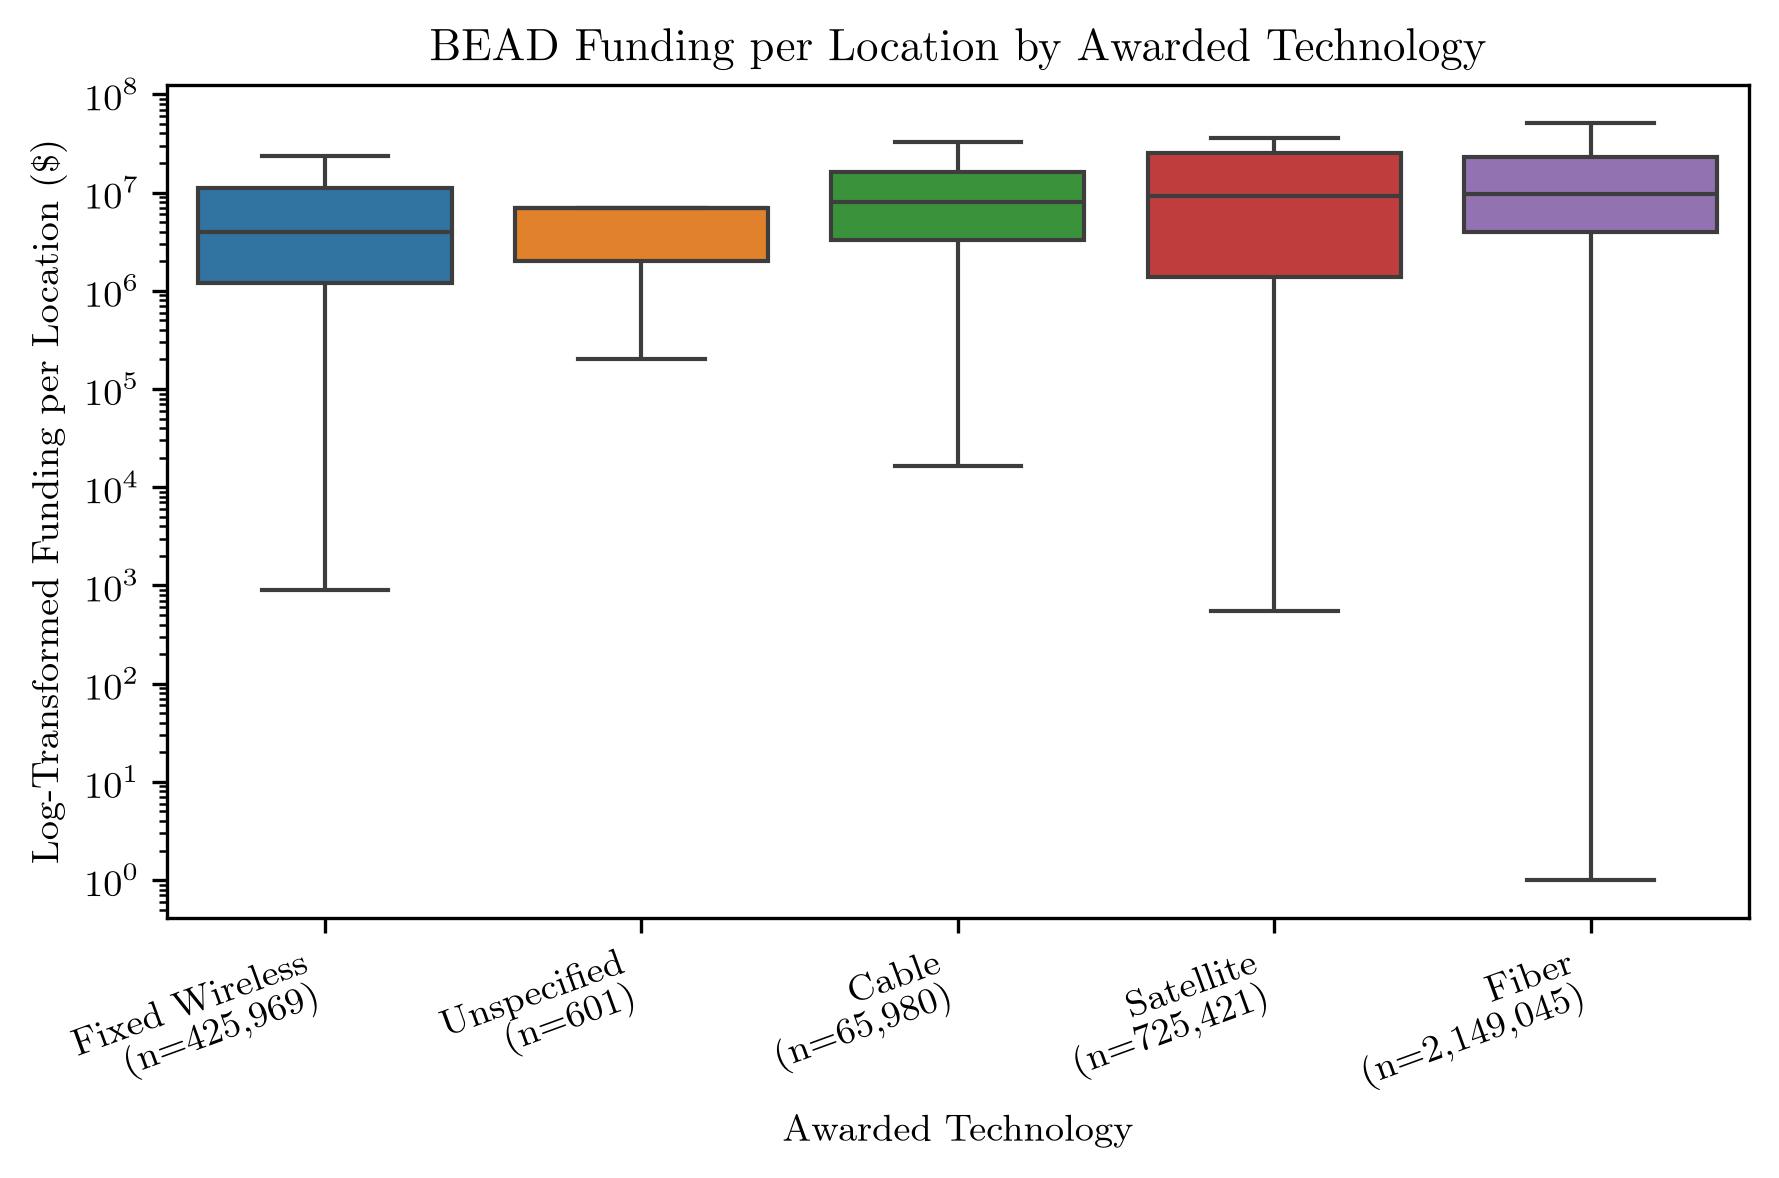

In [26]:
import seaborn as sns
import numpy as np

tech_labels = {0: 'Unspecified', 40: 'Cable', 50: 'Fiber', 61: 'Satellite', 71: 'Fixed Wireless'}

plot_df = df_loc_comp_cp.copy()
plot_df['tech_name'] = plot_df['awarded_technology'].map(tech_labels).fillna('Other')
plot_df = plot_df[plot_df['funding_total'] > 0]

# order by median funding
order = (plot_df.groupby('tech_name')['funding_total'].median()
               .sort_values().index.tolist())
palette = dict(zip(order, sns.color_palette('tab10', len(order))))
counts = plot_df['tech_name'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=plot_df, x='tech_name', y='funding_total',
            order=order, palette=palette, showfliers=False, ax=ax)

ax.set_xticks(range(len(order)))
ax.set_xticklabels([f'{t}\n(n={counts[t]:,})' for t in order], rotation=20, ha='right')
ax.set_yscale('log')
ax.set_xlabel('Awarded Technology')
ax.set_ylabel(r'Log-Transformed Funding per Location (\$)')
ax.set_title('BEAD Funding per Location by Awarded Technology')
plt.tight_layout()
plt.savefig('../eda/plots/bead_funding_per_location_by_tech.png', dpi=300, bbox_inches='tight')
plt.show()

# Dataset Aggregation

In [27]:
df_loc_comp_cp = df_loc_comp_cp[df_loc_comp_cp['awarded_technology'] != 0]
df_loc_comp_cp.shape

(3379054, 37)

In [28]:
def build_enriched_dataset(
    df_locations: pd.DataFrame,
    df_nbm_geo: pd.DataFrame,
    df_poverty: pd.DataFrame,
    df_rucc: pd.DataFrame,
    df_topo: pd.DataFrame,
    df_rugged: pd.DataFrame,
    df_census_housing: pd.DataFrame = None
) -> pd.DataFrame:
    """Join all county-level features to location-level data."""
    
    df = df_locations.copy()
    
    # step 1: join block_geoid from NBM
    df = df.merge(df_nbm_geo, on='location_id', how='left')

    # step 2: join poverty
    pov = df_poverty[["county_id", "B17001_001E", "B17001_002E"]].copy()
    pov["B17001_001E"] = pd.to_numeric(pov["B17001_001E"], errors="coerce")
    pov["B17001_002E"] = pd.to_numeric(pov["B17001_002E"], errors="coerce")
    pov["poverty_rate"] = pov["B17001_002E"] / pov["B17001_001E"].replace(0, np.nan)
    df = df.merge(pov[["county_id", "poverty_rate"]], on="county_id", how="left")
    print(f"After poverty join: {df.shape}, missing poverty_rate: {df['poverty_rate'].isna().sum()}")
    
    # step 3: join RUCC (remoteness)
    rucc = df_rucc[["county_id", "RUCC_2023"]].copy()
    rucc = rucc.rename(columns={"RUCC_2023": "rucc_code"})
    rucc["is_nonmetro"] = (rucc["rucc_code"] >= 4).astype(int)
    df = df.merge(rucc, on="county_id", how="left")
    print(f"After RUCC join: {df.shape}, missing rucc_code: {df['rucc_code'].isna().sum()}")
    
    # step 4: join topography
    topo = df_topo[["county_id", "topography_z", "water_area_pct"]].copy()
    df = df.merge(topo, on="county_id", how="left")
    print(f"After topo join: {df.shape}, missing topography_z: {df['topography_z'].isna().sum()}")
    
    # step 5: join ruggedness
    rugged = df_rugged[["county_id", "RRS", "ARS"]].copy()
    df = df.merge(rugged, on="county_id", how="left")
    print(f"After ruggedness join: {df.shape}, missing RRS: {df['RRS'].isna().sum()}, missing ARS: {df['ARS'].isna().sum()}")

    # step 6: join county housing/density data
    if df_census_housing is not None:
        df = df.merge(df_census_housing, on="county_id", how="left")
        print(f"After housing join: {df.shape}, missing HOUDEN_COU: {df['HOUDEN_COU'].isna().sum()}")
    
    # sanity check
    assert len(df) == len(df_locations), \
        f"Row count changed: {len(df_locations)} -> {len(df)}"
    
    return df

# Run the full pipeline
df_enriched = build_enriched_dataset(
    df_locations=df_loc_comp_cp,
    df_nbm_geo=df_nbm,
    df_poverty=df_poverty,
    df_rucc=df_rucc_wide,
    df_topo=df_topo,
    df_rugged=df_rugged_county,
    df_census_housing=df_county_info,
)

print(f"\nFinal enriched dataset: {df_enriched.shape}")
print(f"New columns: poverty_rate, rucc_code, is_nonmetro, topography_score, water_area_pct")
df_enriched.head()

After poverty join: (3379054, 40), missing poverty_rate: 84866
After RUCC join: (3379054, 42), missing rucc_code: 84866
After topo join: (3379054, 44), missing topography_z: 138741
After ruggedness join: (3379054, 46), missing RRS: 84866, missing ARS: 84866
After housing join: (3379054, 77), missing HOUDEN_COU: 84174

Final enriched dataset: (3379054, 77)
New columns: poverty_rate, rucc_code, is_nonmetro, topography_score, water_area_pct


,location_id,state,awarded_technology,project_id,provider_id,provider_match_method,present_at_location,present_at_location_qualifying,present_same_tech,present_same_tech_qualifying,...,POP_RUR,POPPCT_RUR,HOU_RUR,HOUPCT_RUR,ALAND_RUR,ALAND_Mi²_RUR,ALAND_PCT_RUR,POPDEN_RUR,HOUDEN_RUR,RURALBLOCKS
0,1078346321,MO,50,CM61-BEAD-004088,470022,provider_id,False,False,False,False,...,10032.0,1.0,4312.0,1.0,1.307989e+09,505.014406,1.0,19.86478,8.53837,989.0
1,1078345693,MO,50,CM61-BEAD-004088,470022,provider_id,False,False,False,False,...,10032.0,1.0,4312.0,1.0,1.307989e+09,505.014406,1.0,19.86478,8.53837,989.0
2,1078345753,MO,50,CM61-BEAD-004088,470022,provider_id,False,False,False,False,...,10032.0,1.0,4312.0,1.0,1.307989e+09,505.014406,1.0,19.86478,8.53837,989.0
3,1078345819,MO,50,CM61-BEAD-004088,470022,provider_id,True,False,False,False,...,10032.0,1.0,4312.0,1.0,1.307989e+09,505.014406,1.0,19.86478,8.53837,989.0
4,1078346280,MO,50,CM61-BEAD-004088,470022,provider_id,False,False,False,False,...,10032.0,1.0,4312.0,1.0,1.307989e+09,505.014406,1.0,19.86478,8.53837,989.0


In [29]:
# cast boolean columns to int for modeling
bool_cols = [
    'present_at_location', 'present_at_location_qualifying',
    'present_same_tech', 'present_same_tech_qualifying',
    'competitor_present', 'wired_competitor_present',
    'fiber_competitor_present', 'cable_competitor_present',
    'wireless_competitor_present', 'competitor_present_qualifying',
    'wired_competitor_present_qualifying'
]
df_enriched[bool_cols] = df_enriched[bool_cols].astype(int)

In [30]:
# drop and document
before = len(df_enriched)
df_enriched = df_enriched[df_enriched['county_id'].notna()].reset_index(drop=True)
print(f"Original: {before:,} locations")
print(f"Dropped {before - len(df_enriched):,} locations without fabric match ({(before - len(df_enriched))/before*100:.1f}%)")
print(f"Remaining: {len(df_enriched):,} locations")

Original: 3,379,054 locations
Dropped 84,174 locations without fabric match (2.5%)
Remaining: 3,294,880 locations


In [ ]:
df['sat_co_presence_gap'] = (
    df['frac_sat_competitor_present_qualifying'] 
    - df['frac_sat_only_competitor_qualifying']
)

target = np.log1p(df['funding_per_location'])  # or however y is defined, recompute from df

solo_mask = df['sat_co_presence_gap'] < 0.1
copresent_mask = df['sat_co_presence_gap'] > 0.3

print(f"Satellite mostly solo (n={solo_mask.sum()}):")
print(f"  sat_present ↔ funding: {df.loc[solo_mask, 'frac_sat_competitor_present_qualifying'].corr(target[solo_mask], method='spearman'):+.4f}")

print(f"\nSatellite co-present (n={copresent_mask.sum()}):")
print(f"  sat_present ↔ funding: {df.loc[copresent_mask, 'frac_sat_competitor_present_qualifying'].corr(target[copresent_mask], method='spearman'):+.4f}")

Satellite mostly solo (n=2698):
  sat_present ↔ funding: +0.5116

Satellite co-present (n=1524):
  sat_present ↔ funding: -0.0094


# Model Cleanup

In [ ]:
# drop na's
df_enriched = df_enriched.dropna(subset=['funding_per_location'])

# # Remove top/bottom 2.5% outliers (keep middle 95%)
# low = df['funding_per_location'].quantile(0.025)
# high = df['funding_per_location'].quantile(0.975)
# df = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]
# print(f"After outlier removal: {df.shape[0]} locations")
# print(df['funding_per_location'].describe())

# Location-level Prediction

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GroupShuffleSplit, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_model(X, y, groups, label=""):
    """Group-aware train/test split + 5-fold CV evaluation.

    All rows sharing the same group (project_id) are kept together on one
    side of the split. Since funding_per_location is constant within a
    project, a random location-level split would leak the target: test
    rows would have twin train rows with identical X and y. GroupShuffleSplit
    and GroupKFold prevent that.
    """

    # group-aware 70/30 split
    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]

    # sanity check: no project appears in both train and test
    overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
    assert len(overlap) == 0, f"Group leakage: {len(overlap)} projects in both splits"

    rf = RandomForestRegressor(
        n_estimators=200,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    # test metrics
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    # 5-fold group-aware CV, on train only (leaves test set untouched)
    cv = GroupKFold(n_splits=5)
    cv_r2 = cross_val_score(
        rf, X_train, y_train,
        cv=cv, groups=groups_train, scoring='r2', n_jobs=-1,
    )

    n_train_groups = groups.iloc[train_idx].nunique()
    n_test_groups  = groups.iloc[test_idx].nunique()

    print(f"\n{'='*60}")
    print(f"Model: {label}")
    print(f"Features ({X.shape[1]}): {list(X.columns)}")
    print(f"Observations:          {X.shape[0]:,}")
    print(f"Train / test rows:     {len(train_idx):,} / {len(test_idx):,}")
    print(f"Train / test projects: {n_train_groups:,} / {n_test_groups:,}")
    print(f"Test R²:               {r2:.4f}")
    print(f"Test RMSE ($):         {rmse:,.0f}")
    print(f"Test MAE ($):          {mae:,.0f}")
    print(f"5-fold GroupKFold R²:  {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"{'='*60}")

    return {
        'label': label,
        'n_features': X.shape[1],
        'n_obs': X.shape[0],
        'test_r2': r2,
        'test_rmse': rmse,
        'test_mae': mae,
        'cv_r2_mean': cv_r2.mean(),
        'cv_r2_std': cv_r2.std(),
        'model': rf,
    }

y = df_enriched['funding_per_location']
groups = df_enriched['project_id']
results = {}

In [45]:
df_enriched.groupby('project_id')['county_id'].nunique().describe()

count    5175.000000
mean        2.198841
std         5.600306
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       111.000000
Name: county_id, dtype: float64

## Stage 1: baseline: technology + project structure

In [ ]:
stage1_cols = list(tech_dummies.columns) + [
    'project_total_locations',
    'miles_per_location',
    'jobs_per_location',
    'total_miles',
]

X1 = pd.concat([tech_dummies, df_enriched[stage1_cols[len(tech_dummies.columns):]]], axis=1)
X1 = X1.fillna(X1.median())

results['1_baseline'] = evaluate_model(X1, y, groups, "Stage 1: Technology + Project Structure")


Model: Stage 1: Technology + Project Structure
Features (8): ['tech_40', 'tech_50', 'tech_61', 'tech_71', 'project_total_locations', 'miles_per_location', 'jobs_per_location', 'total_miles']
Observations:          3,294,880
Train / test rows:     2,317,877 / 977,003
Train / test projects: 3,622 / 1,553
Test R²:               -0.1603
Test RMSE ($):         4,607
Test MAE ($):          2,742
5-fold GroupKFold R²:  -0.1207 ± 0.0701


## Stage 2: NTIA cols

In [54]:
ntia_cols = [
    'poverty_rate',
    'rucc_code',
    'is_nonmetro',
    'topography_z',
    'water_area_pct',
    'POPDEN_COU',
    'POPDEN_RUR',
    'HOUDEN_COU',
    'HOUDEN_RUR',
    'ALAND_PCT_RUR',
]

X2 = pd.concat([X1, df_enriched[ntia_cols]], axis=1)
X2 = X2.fillna(X2.median())

results['2_ntia'] = evaluate_model(X2, y, groups, "Stage 2: + NTIA Cost Factors")


Model: Stage 2: + NTIA Cost Factors
Features (17): ['tech_40', 'tech_50', 'tech_61', 'tech_71', 'project_total_locations', 'miles_per_location', 'jobs_per_location', 'poverty_rate', 'rucc_code', 'is_nonmetro', 'topography_z', 'water_area_pct', 'POPDEN_COU', 'POPDEN_RUR', 'HOUDEN_COU', 'HOUDEN_RUR', 'ALAND_PCT_RUR']
Observations:          3,294,880
Train / test rows:     2,317,877 / 977,003
Train / test projects: 3,622 / 1,553
Test R²:               0.0960
Test RMSE ($):         4,067
Test MAE ($):          2,464
5-fold GroupKFold R²:  0.0349 ± 0.2073


## Stage 3: Competition Cols

In [55]:
competition_cols = [
    'competitor_present',
    'wired_competitor_present',
    'fiber_competitor_present',
    'cable_competitor_present',
    'wireless_competitor_present',
    'competitor_present_qualifying',
    'wired_competitor_present_qualifying',
]

# 3a: full dataset with in_nbm flag
X3 = pd.concat([X2, df_enriched[competition_cols].astype(int)], axis=1)
X3 = X3.fillna(X3.median())

results['3_competition_all'] = evaluate_model(X3, y, groups, "Stage 3: + Competition (all locations)")


Model: Stage 3: + Competition (all locations)
Features (24): ['tech_40', 'tech_50', 'tech_61', 'tech_71', 'project_total_locations', 'miles_per_location', 'jobs_per_location', 'poverty_rate', 'rucc_code', 'is_nonmetro', 'topography_z', 'water_area_pct', 'POPDEN_COU', 'POPDEN_RUR', 'HOUDEN_COU', 'HOUDEN_RUR', 'ALAND_PCT_RUR', 'competitor_present', 'wired_competitor_present', 'fiber_competitor_present', 'cable_competitor_present', 'wireless_competitor_present', 'competitor_present_qualifying', 'wired_competitor_present_qualifying']
Observations:          3,294,880
Train / test rows:     2,317,877 / 977,003
Train / test projects: 3,622 / 1,553
Test R²:               0.1636
Test RMSE ($):         3,912
Test MAE ($):          2,357
5-fold GroupKFold R²:  0.1244 ± 0.1786


## Stage 4: Ordinal Encoder

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

state_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
state_encoded = state_enc.fit_transform(df_enriched[['state']])

X4 = X3.copy()
X4['state_encoded'] = state_encoded
results['4_state'] = evaluate_model(X4, y, "Stage 4: + State")

# Location-level Prediction (Log-Transformed)

In [57]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GroupShuffleSplit, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_log_model(X, y, groups, label=""):
    """Group-aware split + 5-fold CV for a model trained on log1p target.

    Log-scale R² is the honest headline metric — that's the scale the model
    optimizes. Dollar-scale RMSE/MAE are reported via Duan smearing to
    correct the Jensen bias from naive expm1 back-transformation. The
    smearing factor is estimated on training residuals only.
    """

    # group-aware 70/30 split
    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]

    # sanity check: no project appears in both train and test
    overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
    assert len(overlap) == 0, f"Group leakage: {len(overlap)} projects in both splits"

    rf = RandomForestRegressor(
        n_estimators=200,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    # log-scale metric (what the model optimizes)
    r2_log = r2_score(y_test, y_pred)

    # dollar-scale metrics with Duan smearing correction
    train_resid = y_train - rf.predict(X_train)
    smear = float(np.mean(np.exp(train_resid)))
    y_test_dollar = np.expm1(y_test)
    y_pred_dollar = np.expm1(y_pred) * smear
    rmse = np.sqrt(mean_squared_error(y_test_dollar, y_pred_dollar))
    mae  = mean_absolute_error(y_test_dollar, y_pred_dollar)

    # 5-fold group-aware CV, on train only (log-scale R²)
    cv = GroupKFold(n_splits=5)
    cv_r2 = cross_val_score(
        rf, X_train, y_train,
        cv=cv, groups=groups_train, scoring='r2', n_jobs=-1,
    )

    n_train_groups = groups.iloc[train_idx].nunique()
    n_test_groups  = groups.iloc[test_idx].nunique()

    print(f"\n{'='*60}")
    print(f"Model: {label}")
    print(f"Features ({X.shape[1]}): {list(X.columns)}")
    print(f"Observations:          {X.shape[0]:,}")
    print(f"Train / test rows:     {len(train_idx):,} / {len(test_idx):,}")
    print(f"Train / test projects: {n_train_groups:,} / {n_test_groups:,}")
    print(f"Test R² (log-scale):   {r2_log:.4f}")
    print(f"Smearing factor:       {smear:.4f}")
    print(f"Test RMSE ($, smeared):{rmse:>10,.0f}")
    print(f"Test MAE  ($, smeared):{mae:>10,.0f}")
    print(f"5-fold GroupKFold R²:  {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"{'='*60}")

    return {
        'label': label,
        'n_features': X.shape[1],
        'n_obs': X.shape[0],
        'test_r2_log': r2_log,
        'test_rmse': rmse,
        'test_mae': mae,
        'smear': smear,
        'cv_r2_mean': cv_r2.mean(),
        'cv_r2_std': cv_r2.std(),
        'model': rf,
    }

y = np.log1p(df_enriched['funding_per_location'])
groups = df_enriched['project_id']
results = {}

In [58]:
df_enriched.groupby('project_id')['county_id'].nunique().describe()

count    5175.000000
mean        2.198841
std         5.600306
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       111.000000
Name: county_id, dtype: float64

## Stage 1: baseline: technology + project structure

In [59]:
tech_dummies = pd.get_dummies(df_enriched['awarded_technology'], prefix='tech', dtype=int)

stage1_cols = list(tech_dummies.columns) + [
    'project_total_locations',
    'miles_per_location',
    'jobs_per_location',
    'total_miles',
]

X1 = pd.concat([tech_dummies, df_enriched[stage1_cols[len(tech_dummies.columns):]]], axis=1)
X1 = X1.fillna(X1.median())

results['1_baseline'] = evaluate_log_model(X1, y, groups, "Stage 1: Technology + Project Structure")


Model: Stage 1: Technology + Project Structure
Features (8): ['tech_40', 'tech_50', 'tech_61', 'tech_71', 'project_total_locations', 'miles_per_location', 'jobs_per_location', 'total_miles']
Observations:          3,294,880
Train / test rows:     2,317,877 / 977,003
Train / test projects: 3,622 / 1,553
Test R² (log-scale):   0.1005
Smearing factor:       1.0040
Test RMSE ($, smeared):     4,103
Test MAE  ($, smeared):     2,501
5-fold GroupKFold R²:  -0.2494 ± 0.2151


## Stage 2: NTIA cols

In [60]:
ntia_cols = [
    'poverty_rate',
    'rucc_code',
    'is_nonmetro',
    'topography_z',
    'water_area_pct',
    'POPDEN_COU',
    'POPDEN_RUR',
    'HOUDEN_COU',
    'HOUDEN_RUR',
    'ALAND_PCT_RUR',
]

X2 = pd.concat([X1, df_enriched[ntia_cols]], axis=1)
X2 = X2.fillna(X2.median())

results['2_ntia'] = evaluate_log_model(X2, y, groups, "Stage 2: + NTIA Cost Factors")


Model: Stage 2: + NTIA Cost Factors
Features (18): ['tech_40', 'tech_50', 'tech_61', 'tech_71', 'project_total_locations', 'miles_per_location', 'jobs_per_location', 'total_miles', 'poverty_rate', 'rucc_code', 'is_nonmetro', 'topography_z', 'water_area_pct', 'POPDEN_COU', 'POPDEN_RUR', 'HOUDEN_COU', 'HOUDEN_RUR', 'ALAND_PCT_RUR']
Observations:          3,294,880
Train / test rows:     2,317,877 / 977,003
Train / test projects: 3,622 / 1,553
Test R² (log-scale):   0.2597
Smearing factor:       1.0001
Test RMSE ($, smeared):     3,608
Test MAE  ($, smeared):     2,290
5-fold GroupKFold R²:  0.0868 ± 0.1996


## Stage 3: Competition Cols

In [61]:
competition_cols = [
    'competitor_present',
    'wired_competitor_present',
    'fiber_competitor_present',
    'cable_competitor_present',
    'wireless_competitor_present',
    'competitor_present_qualifying',
    'wired_competitor_present_qualifying',
]

# 3a: full dataset with in_nbm flag
X3 = pd.concat([X2, df_enriched[competition_cols].astype(int)], axis=1)
X3 = X3.fillna(X3.median())

results['3_competition_all'] = evaluate_log_model(X3, y, groups, "Stage 3: + Competition (all locations)")


Model: Stage 3: + Competition (all locations)
Features (25): ['tech_40', 'tech_50', 'tech_61', 'tech_71', 'project_total_locations', 'miles_per_location', 'jobs_per_location', 'total_miles', 'poverty_rate', 'rucc_code', 'is_nonmetro', 'topography_z', 'water_area_pct', 'POPDEN_COU', 'POPDEN_RUR', 'HOUDEN_COU', 'HOUDEN_RUR', 'ALAND_PCT_RUR', 'competitor_present', 'wired_competitor_present', 'fiber_competitor_present', 'cable_competitor_present', 'wireless_competitor_present', 'competitor_present_qualifying', 'wired_competitor_present_qualifying']
Observations:          3,294,880
Train / test rows:     2,317,877 / 977,003
Train / test projects: 3,622 / 1,553
Test R² (log-scale):   0.3235
Smearing factor:       1.0001
Test RMSE ($, smeared):     3,477
Test MAE  ($, smeared):     2,204
5-fold GroupKFold R²:  0.0772 ± 0.1856


## Stage 4: Ordinal Encoder

In [62]:
from sklearn.preprocessing import OrdinalEncoder

state_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
state_encoded = state_enc.fit_transform(df_enriched[['state']])

X4 = X3.copy()
X4['state_encoded'] = state_encoded
results['4_state'] = evaluate_log_model(X4, y, groups, "Stage 4: + State")


Model: Stage 4: + State
Features (26): ['tech_40', 'tech_50', 'tech_61', 'tech_71', 'project_total_locations', 'miles_per_location', 'jobs_per_location', 'total_miles', 'poverty_rate', 'rucc_code', 'is_nonmetro', 'topography_z', 'water_area_pct', 'POPDEN_COU', 'POPDEN_RUR', 'HOUDEN_COU', 'HOUDEN_RUR', 'ALAND_PCT_RUR', 'competitor_present', 'wired_competitor_present', 'fiber_competitor_present', 'cable_competitor_present', 'wireless_competitor_present', 'competitor_present_qualifying', 'wired_competitor_present_qualifying', 'state_encoded']
Observations:          3,294,880
Train / test rows:     2,317,877 / 977,003
Train / test projects: 3,622 / 1,553
Test R² (log-scale):   0.5047
Smearing factor:       1.0001
Test RMSE ($, smeared):     3,246
Test MAE  ($, smeared):     1,917
5-fold GroupKFold R²:  0.2934 ± 0.1596


In [63]:
df_enriched.groupby('project_id').agg(
      n_comp_rows=('location_id', 'size'),
      n_unique_locs=('location_id', 'nunique'),
  ).head()

,n_comp_rows,n_unique_locs
project_id,,
CM61-BEAD-003953,941,941
CM61-BEAD-003961,3156,3156
CM61-BEAD-003967,552,552
CM61-BEAD-003968,11,11
CM61-BEAD-003969,1133,1133


# Project-level

In [36]:
county_agg = (                                                                                   
      df_enriched
      .groupby(['project_id', 'county_id'])                                                        
      .agg(loc_count=('location_id', 'size'))                                                    
      .reset_index()                      
      .merge(df_enriched[['county_id', 'poverty_rate', 'rucc_code', 'topography_z',
                          'water_area_pct', 'POPDEN_COU', 'HOUDEN_COU',                            
                          'POPDEN_RUR', 'HOUDEN_RUR','RRS', 'ARS', 'ALAND_PCT_RUR']].drop_duplicates('county_id'),                                                  
             on='county_id', how='left')                                                           
  )        

In [37]:
def w_agg(g):                                                                                    
      w = g['loc_count']                                                                         
      out = {}                                                                                     
      for col in ['poverty_rate', 'rucc_code', 'topography_z', 'water_area_pct',                 
                  'POPDEN_COU', 'HOUDEN_COU', 'POPDEN_RUR', 'HOUDEN_RUR', 'RRS', 'ARS','ALAND_PCT_RUR']:
          out[f'{col}_wmean'] = np.average(g[col].fillna(g[col].median()), weights=w)
      out['n_counties'] = g['county_id'].nunique()
      out['poverty_rate_std'] = g['poverty_rate'].std()                                            
      return pd.Series(out)                                                                        
                                                                                                   
proj_county_features = county_agg.groupby('project_id').apply(w_agg).reset_index()    

In [38]:
comp_shares = df_enriched.groupby('project_id')[                                                 
      ['competitor_present_qualifying',
      'competitor_present_qualifying_no_sat',
      'present_at_location',
      'wireless_competitor_present',
      'wireless_competitor_present_qualifying',
      'wired_competitor_present',
      'wired_competitor_present_qualifying',
      'fiber_competitor_present',
      'fiber_competitor_present_qualifying',
      'cable_competitor_present',
      'cable_competitor_present_qualifying',
      'sat_competitor_present_qualifying',
      'sat_only_competitor_qualifying']                   
  ].mean().add_prefix('frac_').reset_index()      

In [39]:
# Load and prepare data (same pipeline as bead_rf_final)
df_projects = client.query("""
SELECT project_id, state, bead_support, estimated_miles_aerial_fiber,
       estimated_miles_buried_fiber, estimated_jobs
FROM `broadband-data.fp_approved.deployment_projects`
""").to_dataframe()

df_locations = client.query("""
SELECT project_id, COUNT(*) AS funded_locations,
       SAFE_CAST(APPROX_TOP_COUNT(CAST(technology AS STRING), 1)[OFFSET(0)].value AS FLOAT64) AS technology
FROM `broadband-data.fp_approved.locations`
GROUP BY project_id
""").to_dataframe()

state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New_Hampshire': 'NH',
    'New_Jersey': 'NJ', 'New_Mexico': 'NM', 'New_York': 'NY', 'North_Carolina': 'NC',
    'North_Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode_Island': 'RI', 'South_Carolina': 'SC', 'South_Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West_Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District_of_Columbia': 'DC'
}
df_state_num = client.query("SELECT state, COUNT(DISTINCT frn) AS state_num_providers FROM `broadband-data.fcc_nbm.nbm_hive` GROUP BY state").to_dataframe()
df_state_num['state'] = df_state_num['state'].map(state_name_to_abbr)
df_state_num = df_state_num.dropna(subset=['state'])
df_state_pop = client.query("SELECT stateabbr AS state, SUM(pop2020) AS state_population FROM `broadband-data.fcc_block_level_pop.us2020` GROUP BY stateabbr").to_dataframe()

df = df_projects.merge(df_locations, on='project_id', how='left')
df = df.merge(df_state_num, on='state', how='left')
df = df.merge(df_state_pop, on='state', how='left')
df['funded_locations'] = df['funded_locations'].fillna(0)
df['technology'] = df['technology'].fillna(0)
df['state_num_providers'] = df['state_num_providers'].fillna(0)
df['state_population'] = df['state_population'].fillna(0)
df['total_fiber_miles'] = df['estimated_miles_aerial_fiber'].fillna(0) + df['estimated_miles_buried_fiber'].fillna(0)
df['miles_per_location'] = df['total_fiber_miles'] / df['funded_locations'].replace(0, np.nan)
df['miles_per_location'] = df['miles_per_location'].fillna(0)
df['jobs_per_location'] = df['estimated_jobs'] / df['funded_locations'].replace(0, np.nan)
df['jobs_per_location'] = df['jobs_per_location'].fillna(0)
df['funding_per_location'] = df['bead_support'] / df['funded_locations'].replace(0, np.nan)
df = df.dropna(subset=['funding_per_location'])
# low = df['funding_per_location'].quantile(0.025)
# high = df['funding_per_location'].quantile(0.975)
# df = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]
df['log_funding'] = np.log1p(df['funding_per_location'])

In [40]:
missing_ids = set(df_projects['project_id']) - set(df_enriched['project_id'].unique())
print(f"Missing: {len(missing_ids)}")

# what do these projects look like?
df_missing = df_projects[df_projects['project_id'].isin(missing_ids)]

Missing: 76


In [41]:
low = df['funding_per_location'].quantile(0.025)
high = df['funding_per_location'].quantile(0.975)
df_trimmed = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GroupShuffleSplit, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Combine project-level df (state features) with weighted county aggregates and
# competition shares from df_enriched. One row per project, random 80/20 split.
results = {}

df_full = (
    df_trimmed
    .merge(proj_county_features, on='project_id', how='left')
    .merge(comp_shares, on='project_id', how='left')
)
print(f"df_full: {df_full.shape}, projects with any county match: "
      f"{df_full['n_counties'].notna().sum():,}")

county_wmean_cols = [c for c in df_full.columns if c.endswith('_wmean')]
comp_share_cols   = [c for c in df_full.columns if c.startswith('frac_')]

# feature_cols_full = (
#     ['miles_per_location', 'jobs_per_location', 'total_fiber_miles',
#      'funded_locations', 'technology',
#      'state_population', 'state_num_providers',
#      'n_counties', 'poverty_rate_std']
#     + county_wmean_cols
#     + comp_share_cols
# )

feature_cols_full = [
    "miles_per_location",
    "frac_sat_only_competitor_qualifying",
    "state_population",
    "frac_present_at_location",
    "technology",
    "state_num_providers",
    "jobs_per_location",
    "frac_sat_competitor_present_qualifying",
    "funded_locations",
    "total_fiber_miles",
    "HOUDEN_RUR_wmean",
    "topography_z_wmean"
]

X = df_full[feature_cols_full].fillna(df_full[feature_cols_full].median(numeric_only=True))
y = df_full['log_funding']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# log-scale metric
r2_log = r2_score(y_test, y_pred)

# dollar-scale with Duan smearing (correct back-transform bias)
train_resid = y_train - rf.predict(X_train)
smear = float(np.mean(np.exp(train_resid)))
y_test_dollar = np.expm1(y_test)
y_pred_dollar = np.expm1(y_pred) * smear
rmse = np.sqrt(mean_squared_error(y_test_dollar, y_pred_dollar))
mae  = mean_absolute_error(y_test_dollar, y_pred_dollar)

# 5-fold CV (plain KFold — each project is one row, no group leakage possible)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)

print(f"\n{'='*70}")
print(f"Project-level RF: state + project + county wmeans + comp shares")
print(f"Features ({X.shape[1]}): {feature_cols_full}")
print(f"Projects:              {X.shape[0]:,}")
print(f"Train / test:          {len(X_train):,} / {len(X_test):,}")
print(f"Test R² (log-scale):   {r2_log:.4f}")
print(f"Smearing factor:       {smear:.4f}")
print(f"Test RMSE ($, smeared):{rmse:>10,.0f}")
print(f"Test MAE  ($, smeared):{mae:>10,.0f}")
print(f"5-fold CV R²:          {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"{'='*70}")

results['project_level_full'] = {
    'test_r2_log': r2_log, 'test_rmse': rmse, 'test_mae': mae,
    'smear': smear, 'cv_r2_mean': cv_r2.mean(), 'cv_r2_std': cv_r2.std(),
    'model': rf, 'features': feature_cols_full,
}

df_full: (4966, 41), projects with any county match: 4,919

Project-level RF: state + project + county wmeans + comp shares
Features (12): ['miles_per_location', 'frac_sat_only_competitor_qualifying', 'state_population', 'frac_present_at_location', 'technology', 'state_num_providers', 'jobs_per_location', 'frac_sat_competitor_present_qualifying', 'funded_locations', 'total_fiber_miles', 'HOUDEN_RUR_wmean', 'topography_z_wmean']
Projects:              4,966
Train / test:          3,476 / 1,490
Test R² (log-scale):   0.7673
Smearing factor:       1.0260
Test RMSE ($, smeared):     2,190
Test MAE  ($, smeared):     1,261
5-fold CV R²:          0.7680 ± 0.0178


In [ ]:
# SHAP interaction values reveal which pairs of features
# jointly influence predictions beyond their individual effects
import shap

explainer = shap.TreeExplainer(rf)
shap_interaction = explainer.shap_interaction_values(X_test.sample(500, random_state=42))

# sum absolute interaction values per feature pair
n_features = X_test.shape[1]
interaction_matrix = np.abs(shap_interaction).mean(axis=0)
np.fill_diagonal(interaction_matrix, 0)  # remove self-interaction

# top interactions
pairs = []
for i in range(n_features):
    for j in range(i+1, n_features):
        pairs.append((X_test.columns[i], X_test.columns[j], interaction_matrix[i, j]))

pairs.sort(key=lambda x: -x[2])
print("Top feature interactions:")
for f1, f2, val in pairs[:10]:
    print(f"  {f1} × {f2}: {val:.4f}")

Top feature interactions:
  miles_per_location × state_population: 0.0443
  miles_per_location × frac_present_at_location: 0.0435
  miles_per_location × frac_sat_only_competitor_qualifying: 0.0432
  miles_per_location × technology: 0.0365
  miles_per_location × state_num_providers: 0.0236
  frac_present_at_location × technology: 0.0226
  miles_per_location × HOUDEN_RUR_wmean: 0.0211
  technology × frac_sat_competitor_present_qualifying: 0.0208
  frac_sat_only_competitor_qualifying × jobs_per_location: 0.0204
  miles_per_location × total_fiber_miles: 0.0192


Text(0.97, 0.08, '$R^2 = 0.7673$')

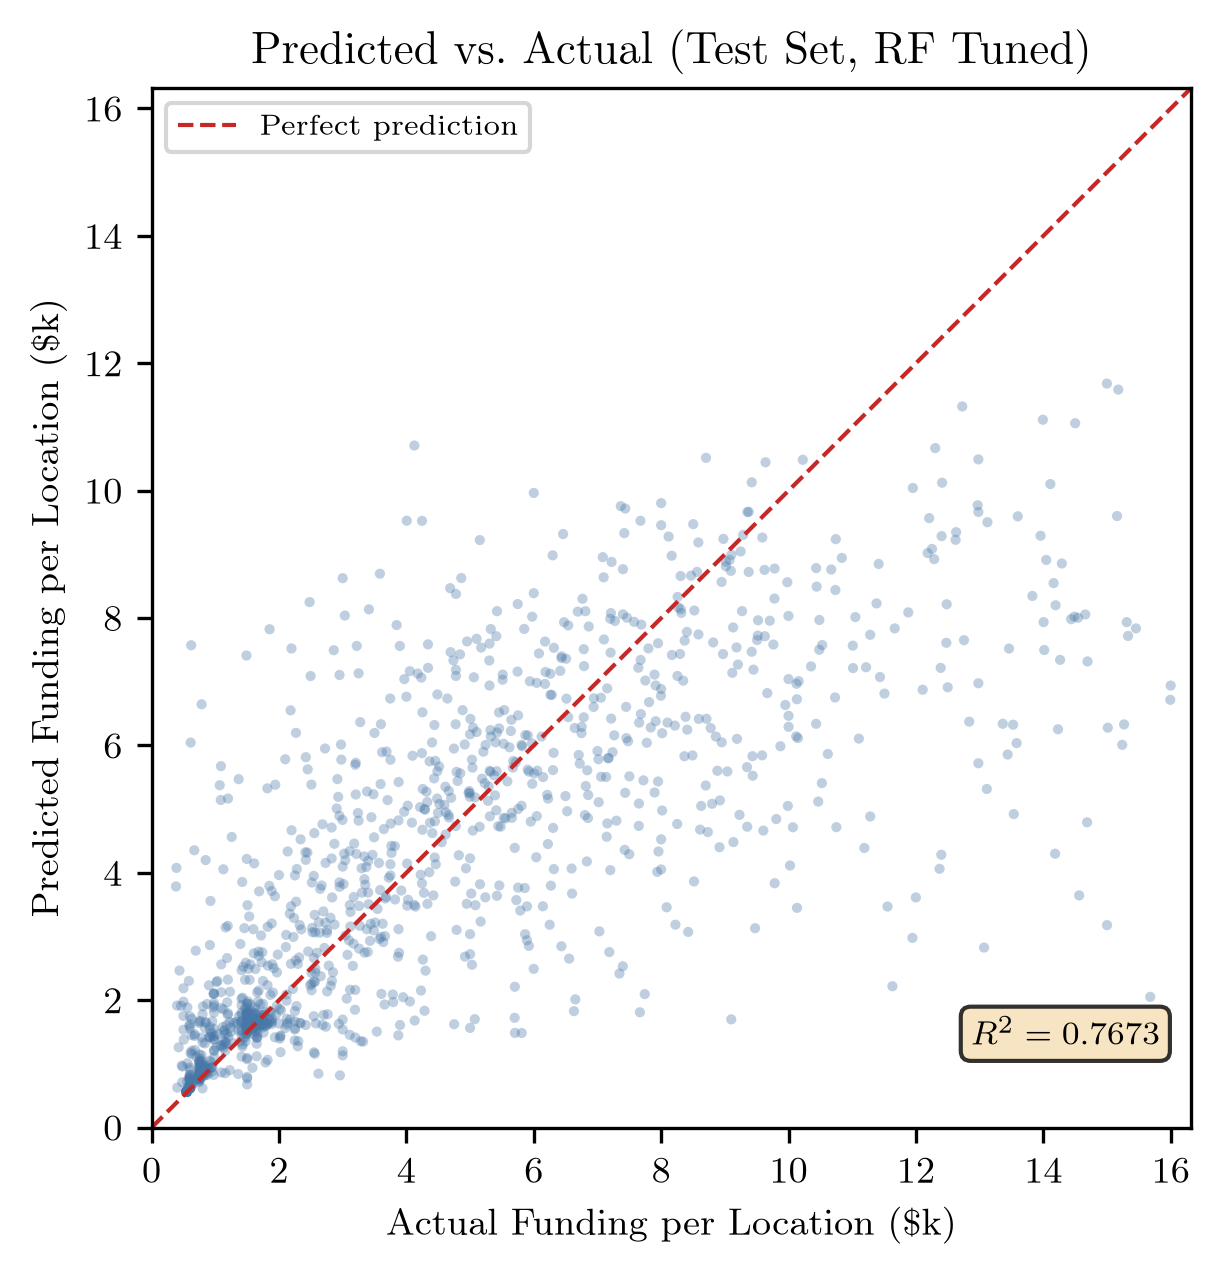

In [46]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(y_test_dollar / 1000, y_pred_dollar / 1000,
           s=6, alpha=0.35, color='#4878A8', edgecolors='none', rasterized=True)

lims = [0, max(y_test_dollar.max(), y_pred_dollar.max()) / 1000 * 1.02]
ax.plot(lims, lims, '--', color='#C62828', lw=1.0, label='Perfect prediction')

ax.set_xlabel('Actual Funding per Location (\\$k)' if HAS_LATEX else 'Actual Funding per Location ($k)')
ax.set_ylabel('Predicted Funding per Location (\\$k)' if HAS_LATEX else 'Predicted Funding per Location ($k)')
ax.set_title('Predicted vs.\\ Actual (Test Set, RF Tuned)' if HAS_LATEX else 'Predicted vs. Actual (Test Set, RF Tuned)', weight='bold')
ax.legend(fontsize=7, loc='upper left')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')

r2_label = f'$R^2 = {r2_log:.4f}$' if HAS_LATEX else f'R² = {r2_log:.4f}'
ax.text(0.97, 0.08, r2_label,
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

Permutation importance (drop in test R² when feature is shuffled)
                               feature perm_mean perm_std   gini
                    miles_per_location   +0.7600   0.0164 0.5948
   frac_sat_only_competitor_qualifying   +0.1267   0.0053 0.0470
                      state_population   +0.1094   0.0027 0.0656
                            technology   +0.1088   0.0069 0.0287
              frac_present_at_location   +0.0922   0.0080 0.0445
                     jobs_per_location   +0.0432   0.0044 0.0398
                   state_num_providers   +0.0431   0.0031 0.0413
                      HOUDEN_RUR_wmean   +0.0228   0.0030 0.0396
                    topography_z_wmean   +0.0183   0.0023 0.0312
frac_sat_competitor_present_qualifying   +0.0180   0.0024 0.0171
                     total_fiber_miles   +0.0172   0.0017 0.0192
                      funded_locations   +0.0134   0.0026 0.0313


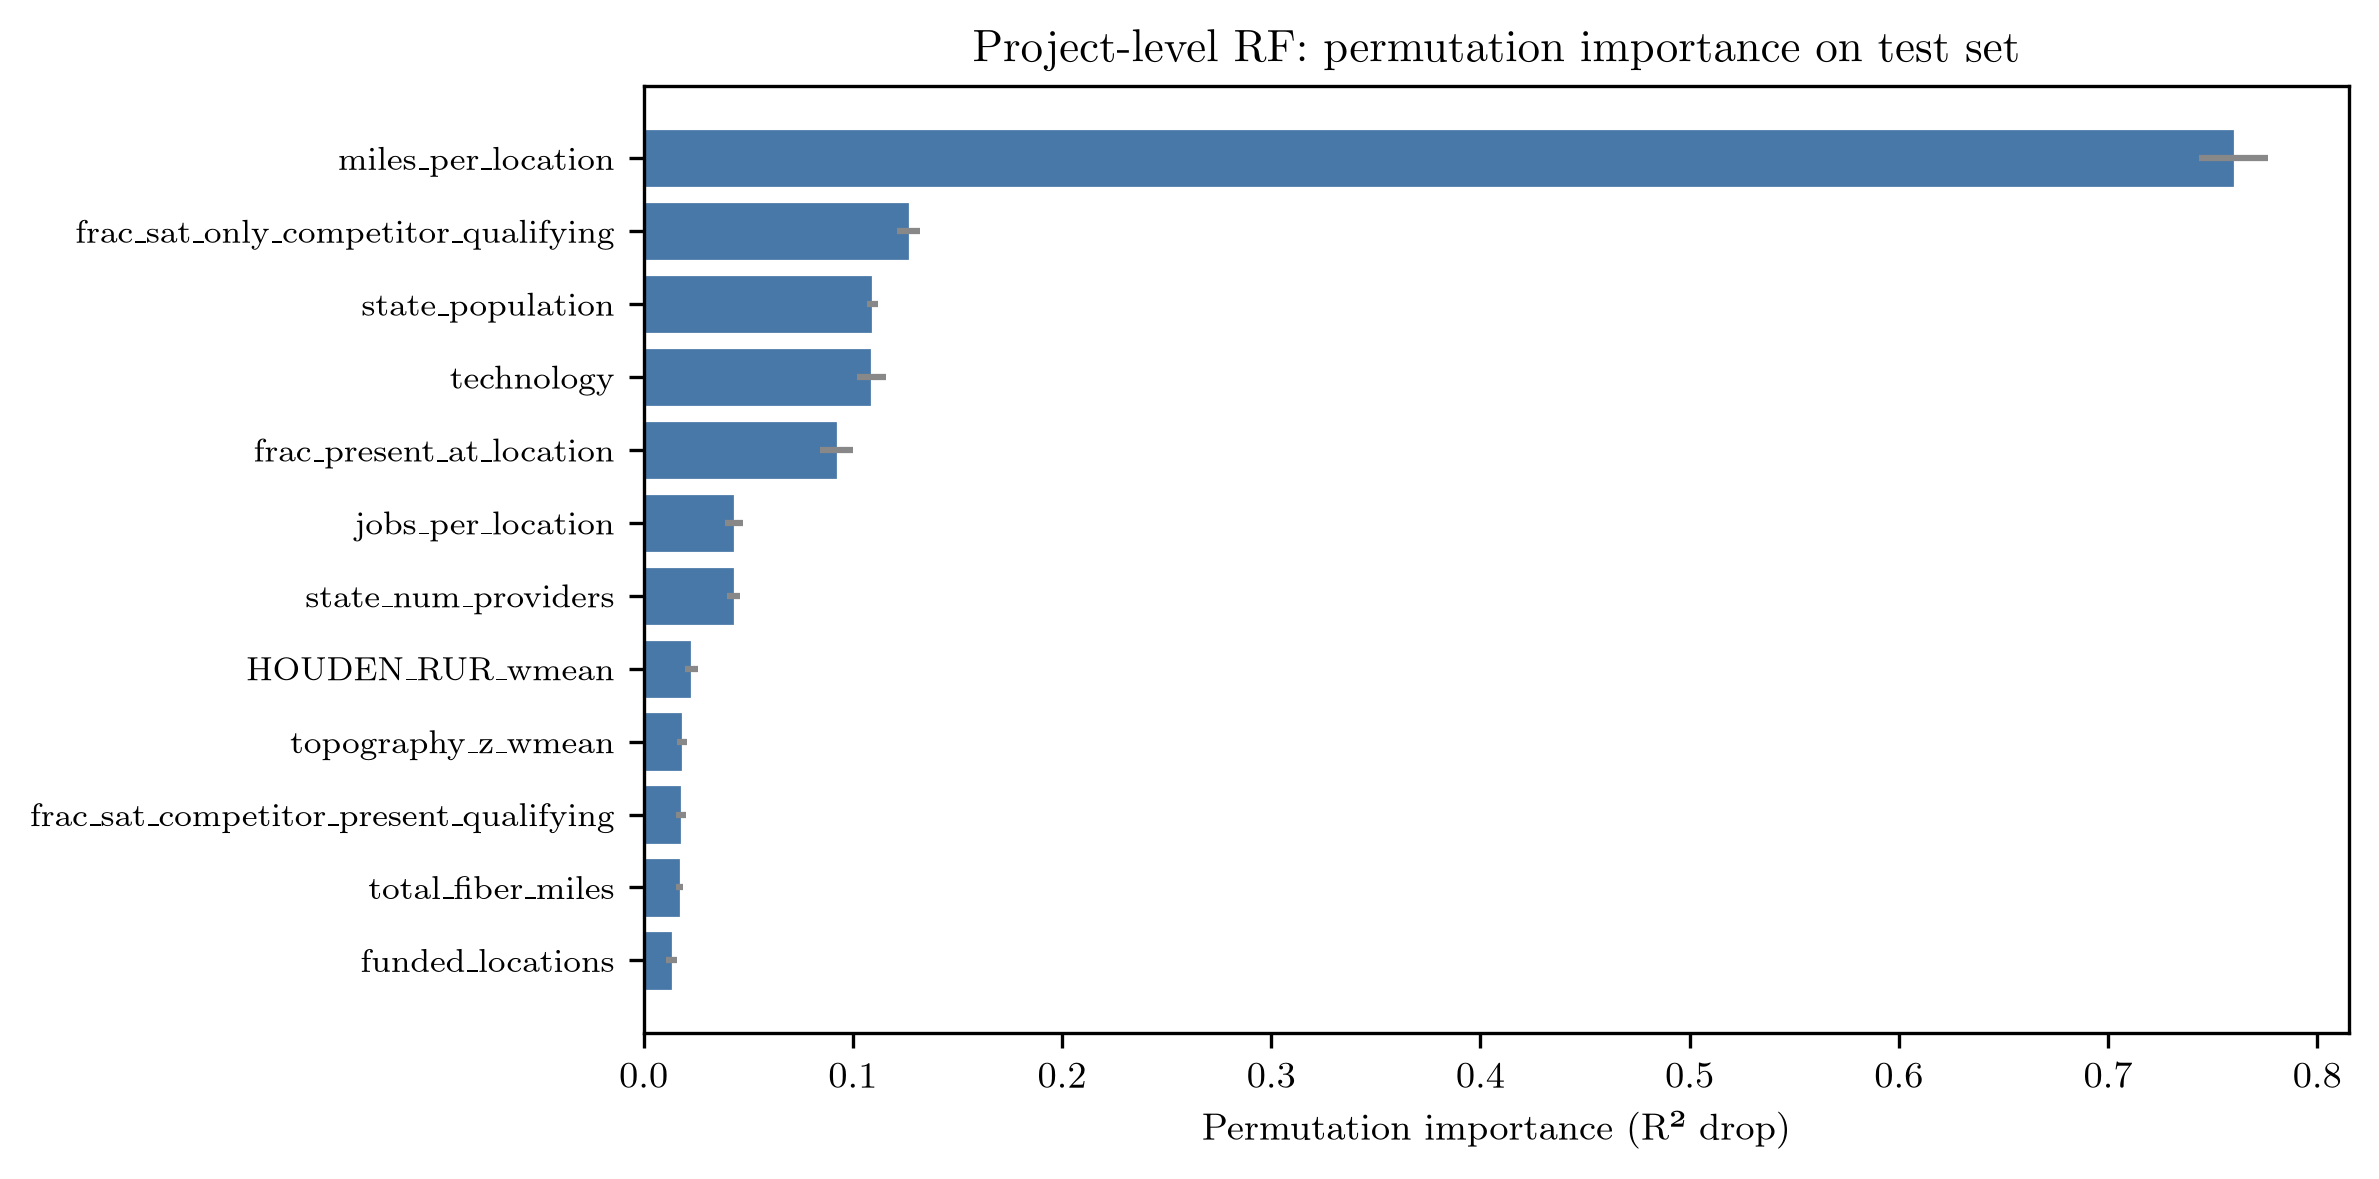


Features with |perm_mean| < perm_std (candidates to drop): 0


In [47]:
# Permutation importance: shuffles each feature on the TEST set and measures the R² drop
# Unlike Gini importance, measures what the model actually relies on for generalization

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf, X_test, y_test,
    scoring='r2',
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_df = (
    pd.DataFrame({
        'feature': feature_cols_full,
        'perm_mean': perm.importances_mean,
        'perm_std': perm.importances_std,
        'gini': rf.feature_importances_,
    })
    .sort_values('perm_mean', ascending=False)
    .reset_index(drop=True)
)

print(f"Permutation importance (drop in test R² when feature is shuffled)")
print(f"{'='*70}")
print(perm_df.to_string(index=False,
      formatters={'perm_mean': '{:+.4f}'.format,
                  'perm_std':  '{:.4f}'.format,
                  'gini':      '{:.4f}'.format}))

# Plot
fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(perm_df))))
order = perm_df.sort_values('perm_mean', ascending=True)
ax.barh(order['feature'], order['perm_mean'],
        xerr=order['perm_std'], color='#4878A8', ecolor='#888',
        edgecolor='white', linewidth=0.3)
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel('Permutation importance (R² drop)')
ax.set_title('Project-level RF: permutation importance on test set',
             weight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

# Flag features with essentially zero generalization value
noise_features = perm_df.loc[
    perm_df['perm_mean'] < perm_df['perm_std'], 'feature'
].tolist()
print(f"\nFeatures with |perm_mean| < perm_std (candidates to drop): "
      f"{len(noise_features)}")
for f in noise_features:
    print(f"  - {f}")

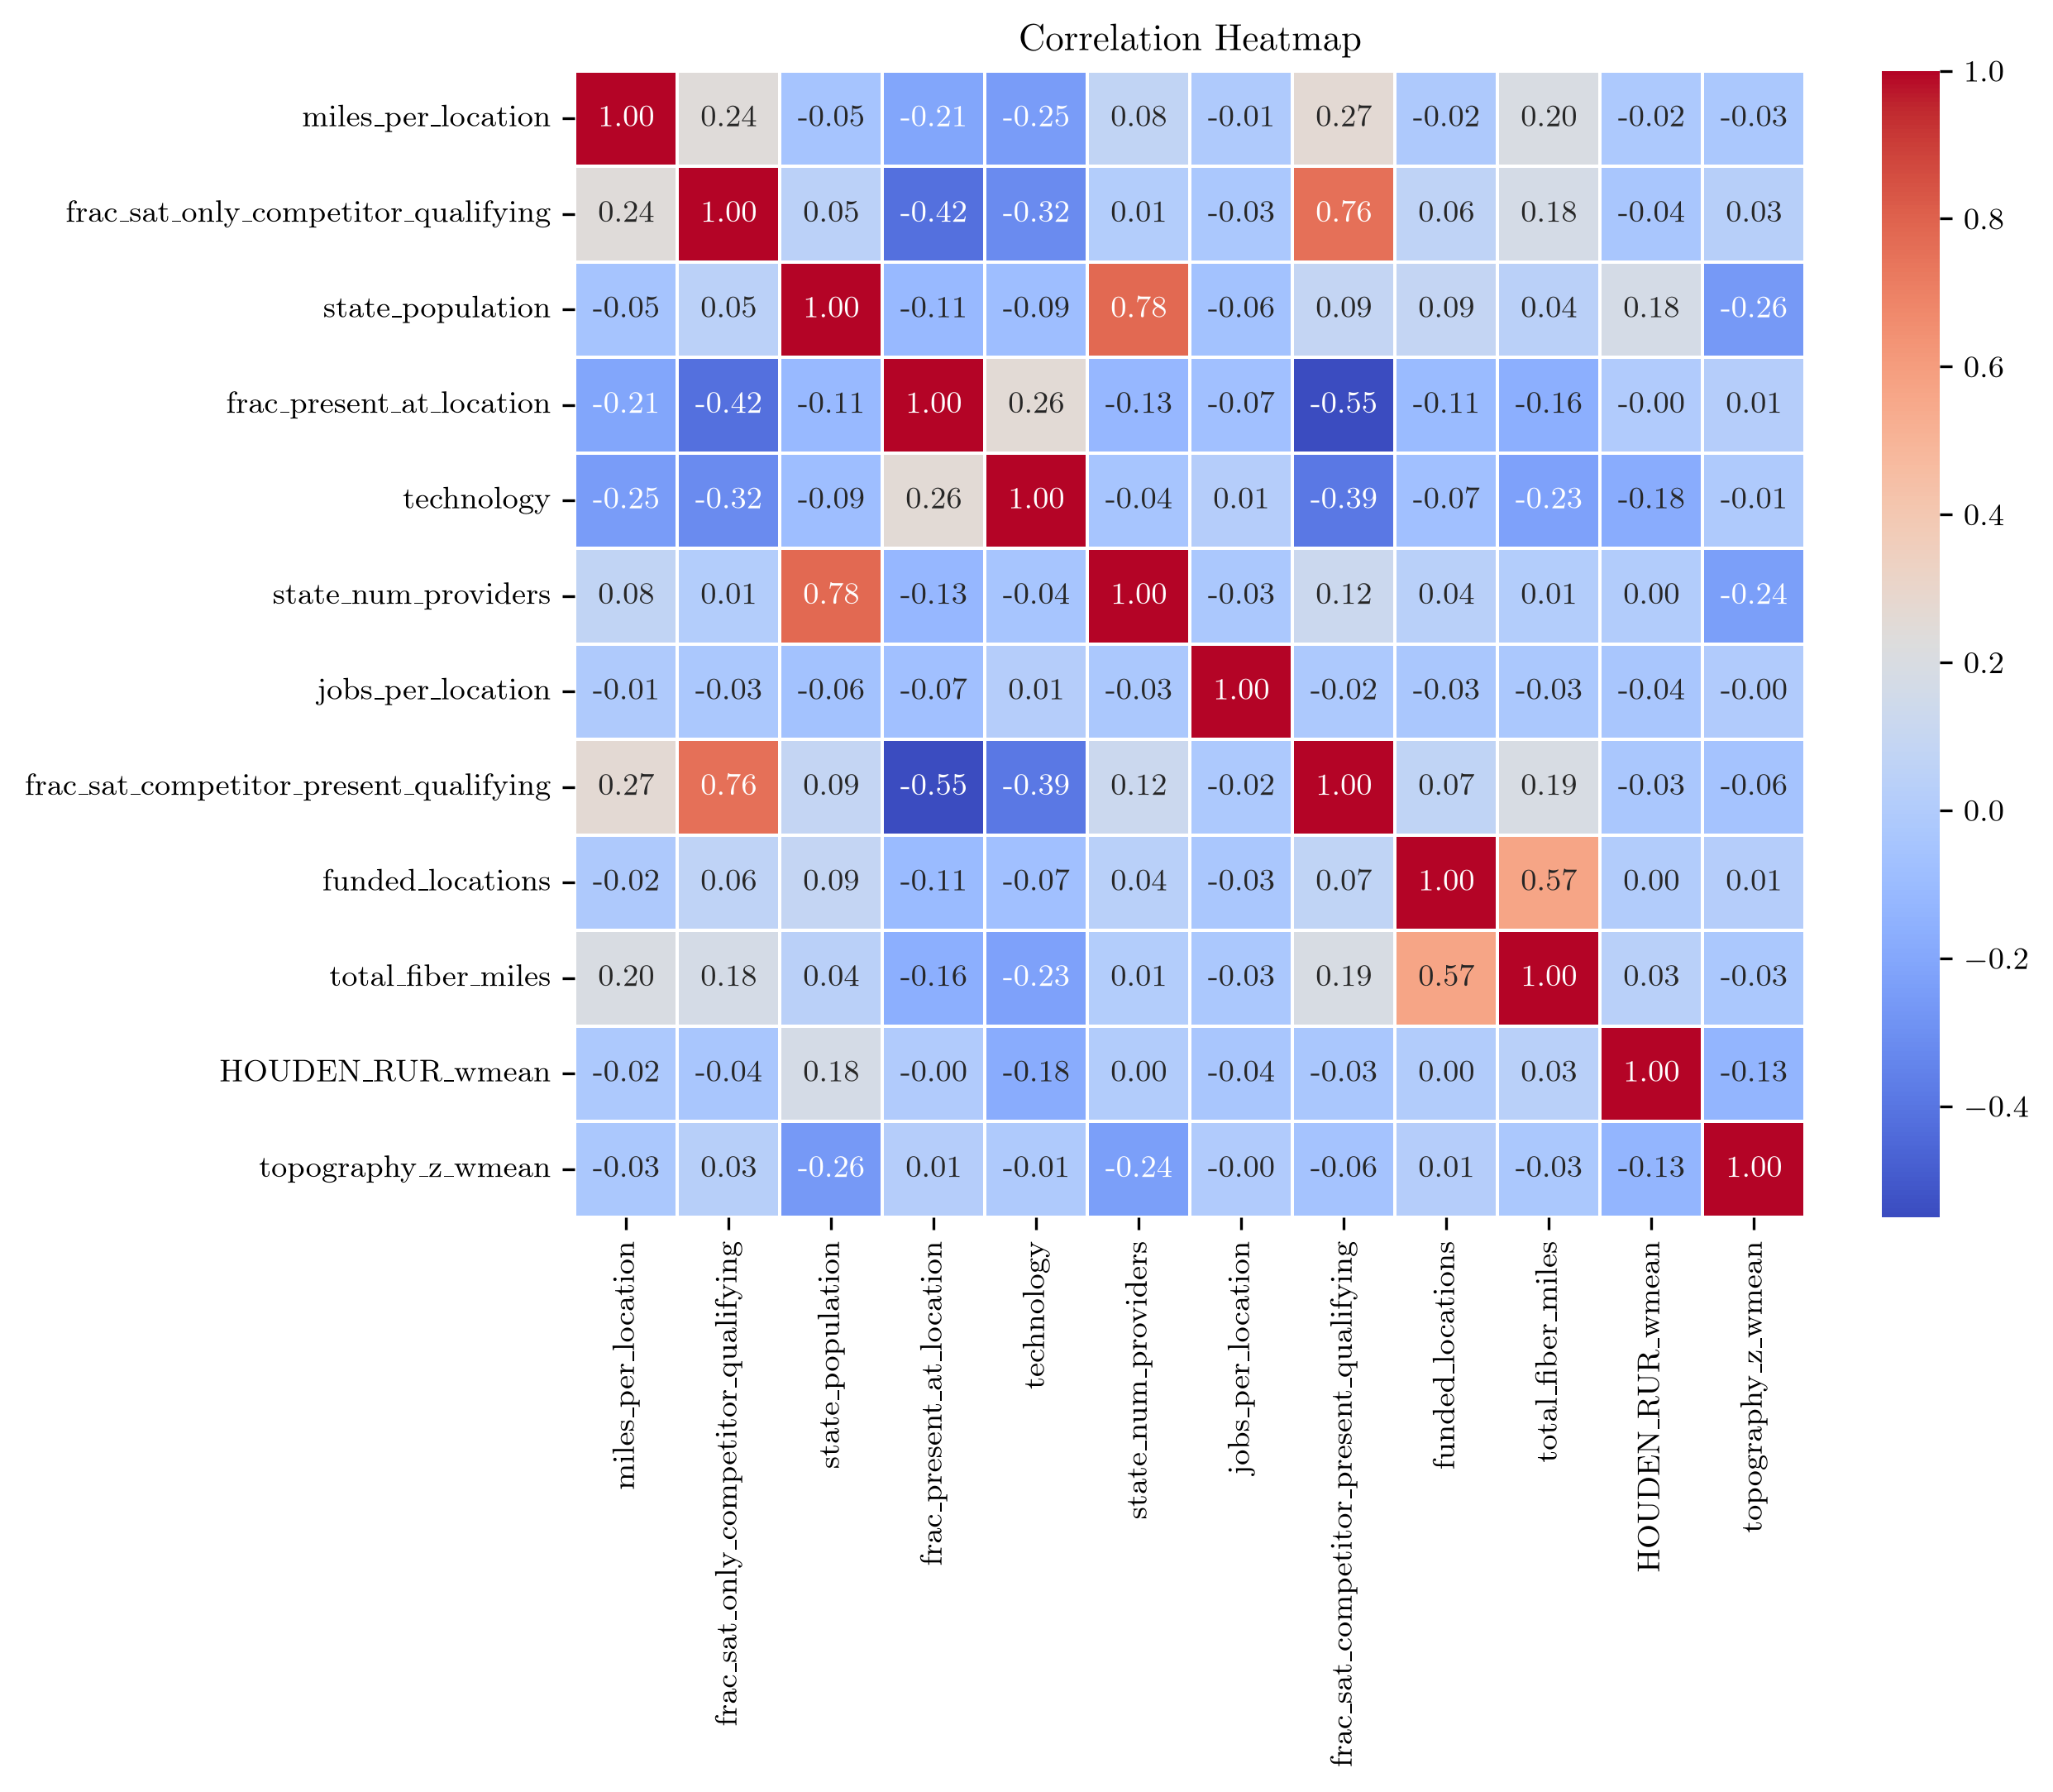

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

matrix = X_train.corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

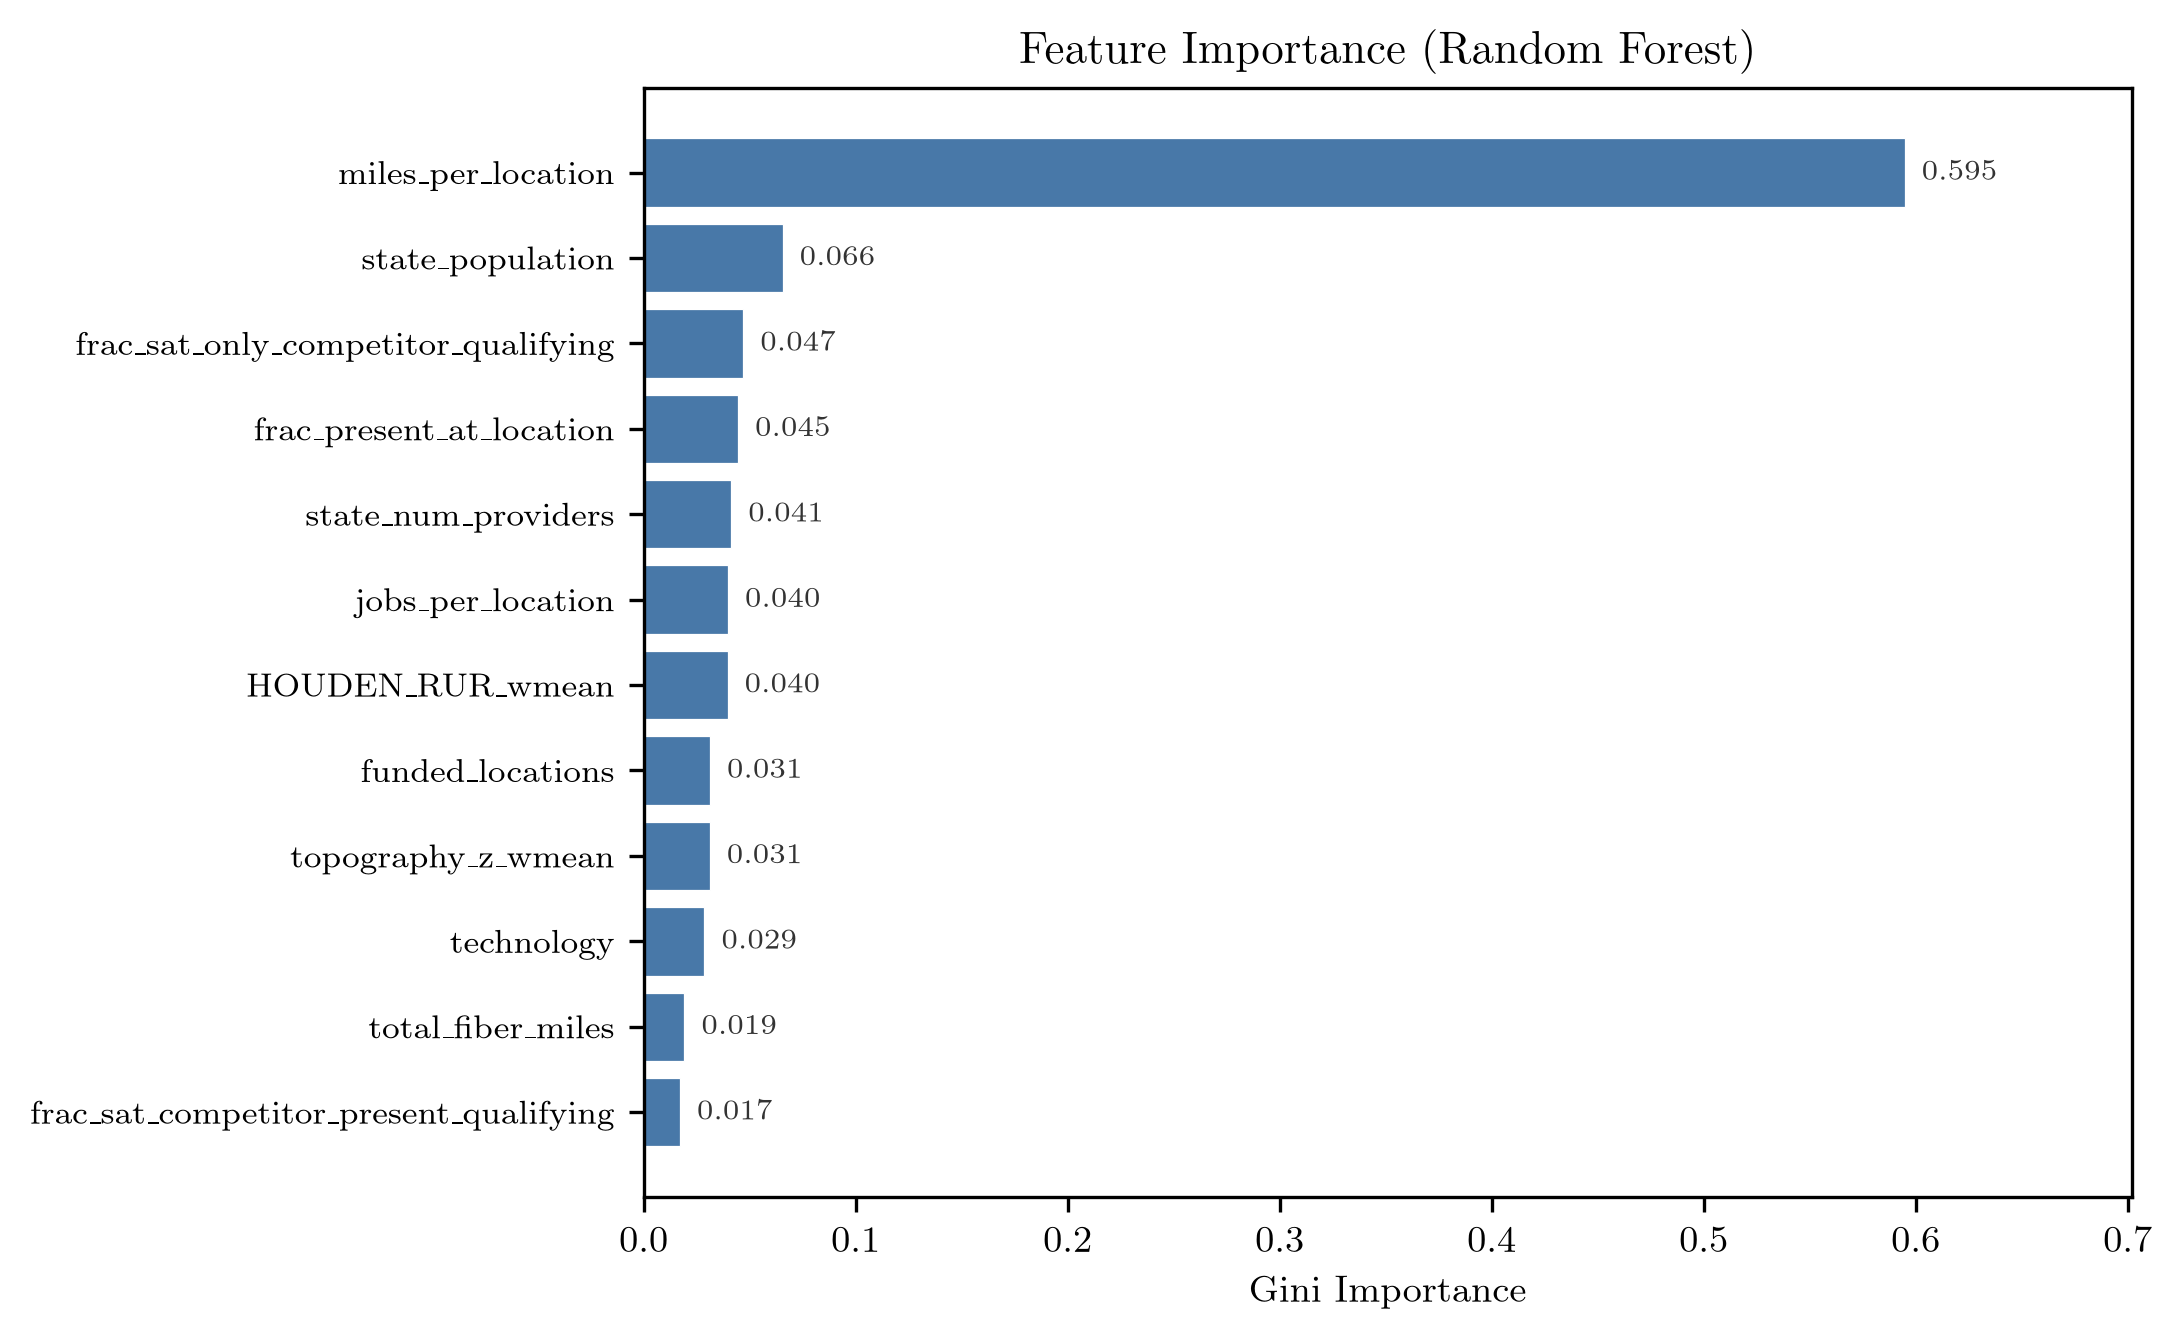

Saved: fig_feature_importance.pdf / .png


In [49]:
# ============================================================
# Figure 1: Feature Importance (Gini impurity-based)
# ============================================================
imp = pd.Series(rf.feature_importances_, index=feature_cols_full)
imp = imp.sort_values()

fig, ax = plt.subplots()
bars = ax.barh(imp.index, imp.values, color='#4878A8', edgecolor='white', linewidth=0.3)

# Annotate values
for bar, val in zip(bars, imp.values):
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7, color='#333')

ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importance (Random Forest)', weight='bold')
ax.set_xlim(0, imp.max() * 1.18)
ax.tick_params(axis='y', labelsize=8)

plt.savefig('fig_feature_importance.pdf')
plt.savefig('fig_feature_importance.png')
plt.show()
print('Saved: fig_feature_importance.pdf / .png')

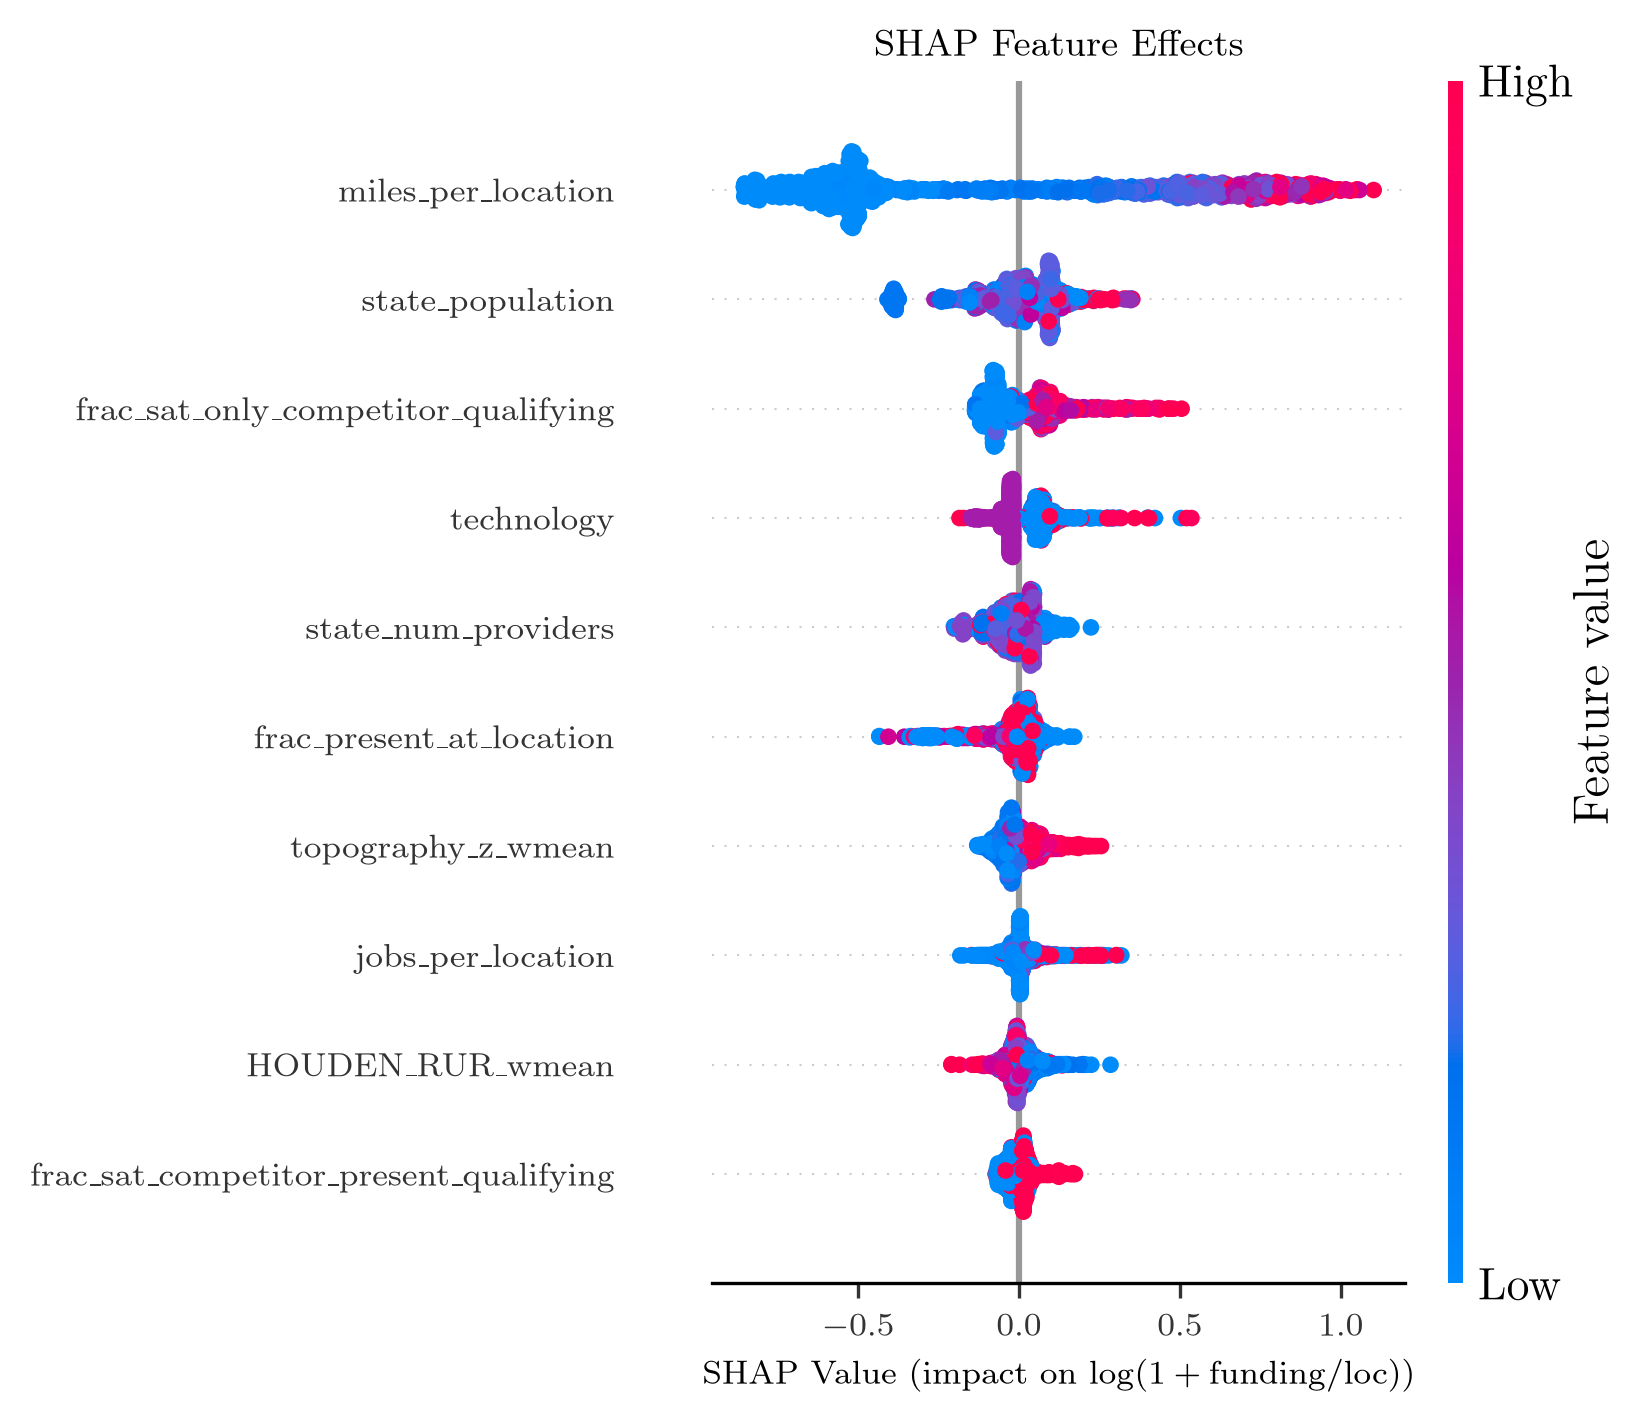

Saved: fig_shap_beeswarm.pdf / .png


In [ ]:
# ============================================================
# Figure 2: SHAP Beeswarm Summary Plot
# ============================================================
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots()
shap.summary_plot(shap_values, X_test,
                  show=False, plot_size=None, max_display=10)
ax = plt.gca()
ax.set_xlabel('SHAP Value (impact on $\\log(1+\\mathrm{funding/loc})$)', fontsize=8)
ax.set_title('SHAP Feature Effects', weight='bold', fontsize=9)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)

plt.savefig('fig_shap_beeswarm.pdf')
plt.savefig('fig_shap_beeswarm.png')
plt.show()
print('Saved: fig_shap_beeswarm.pdf / .png')

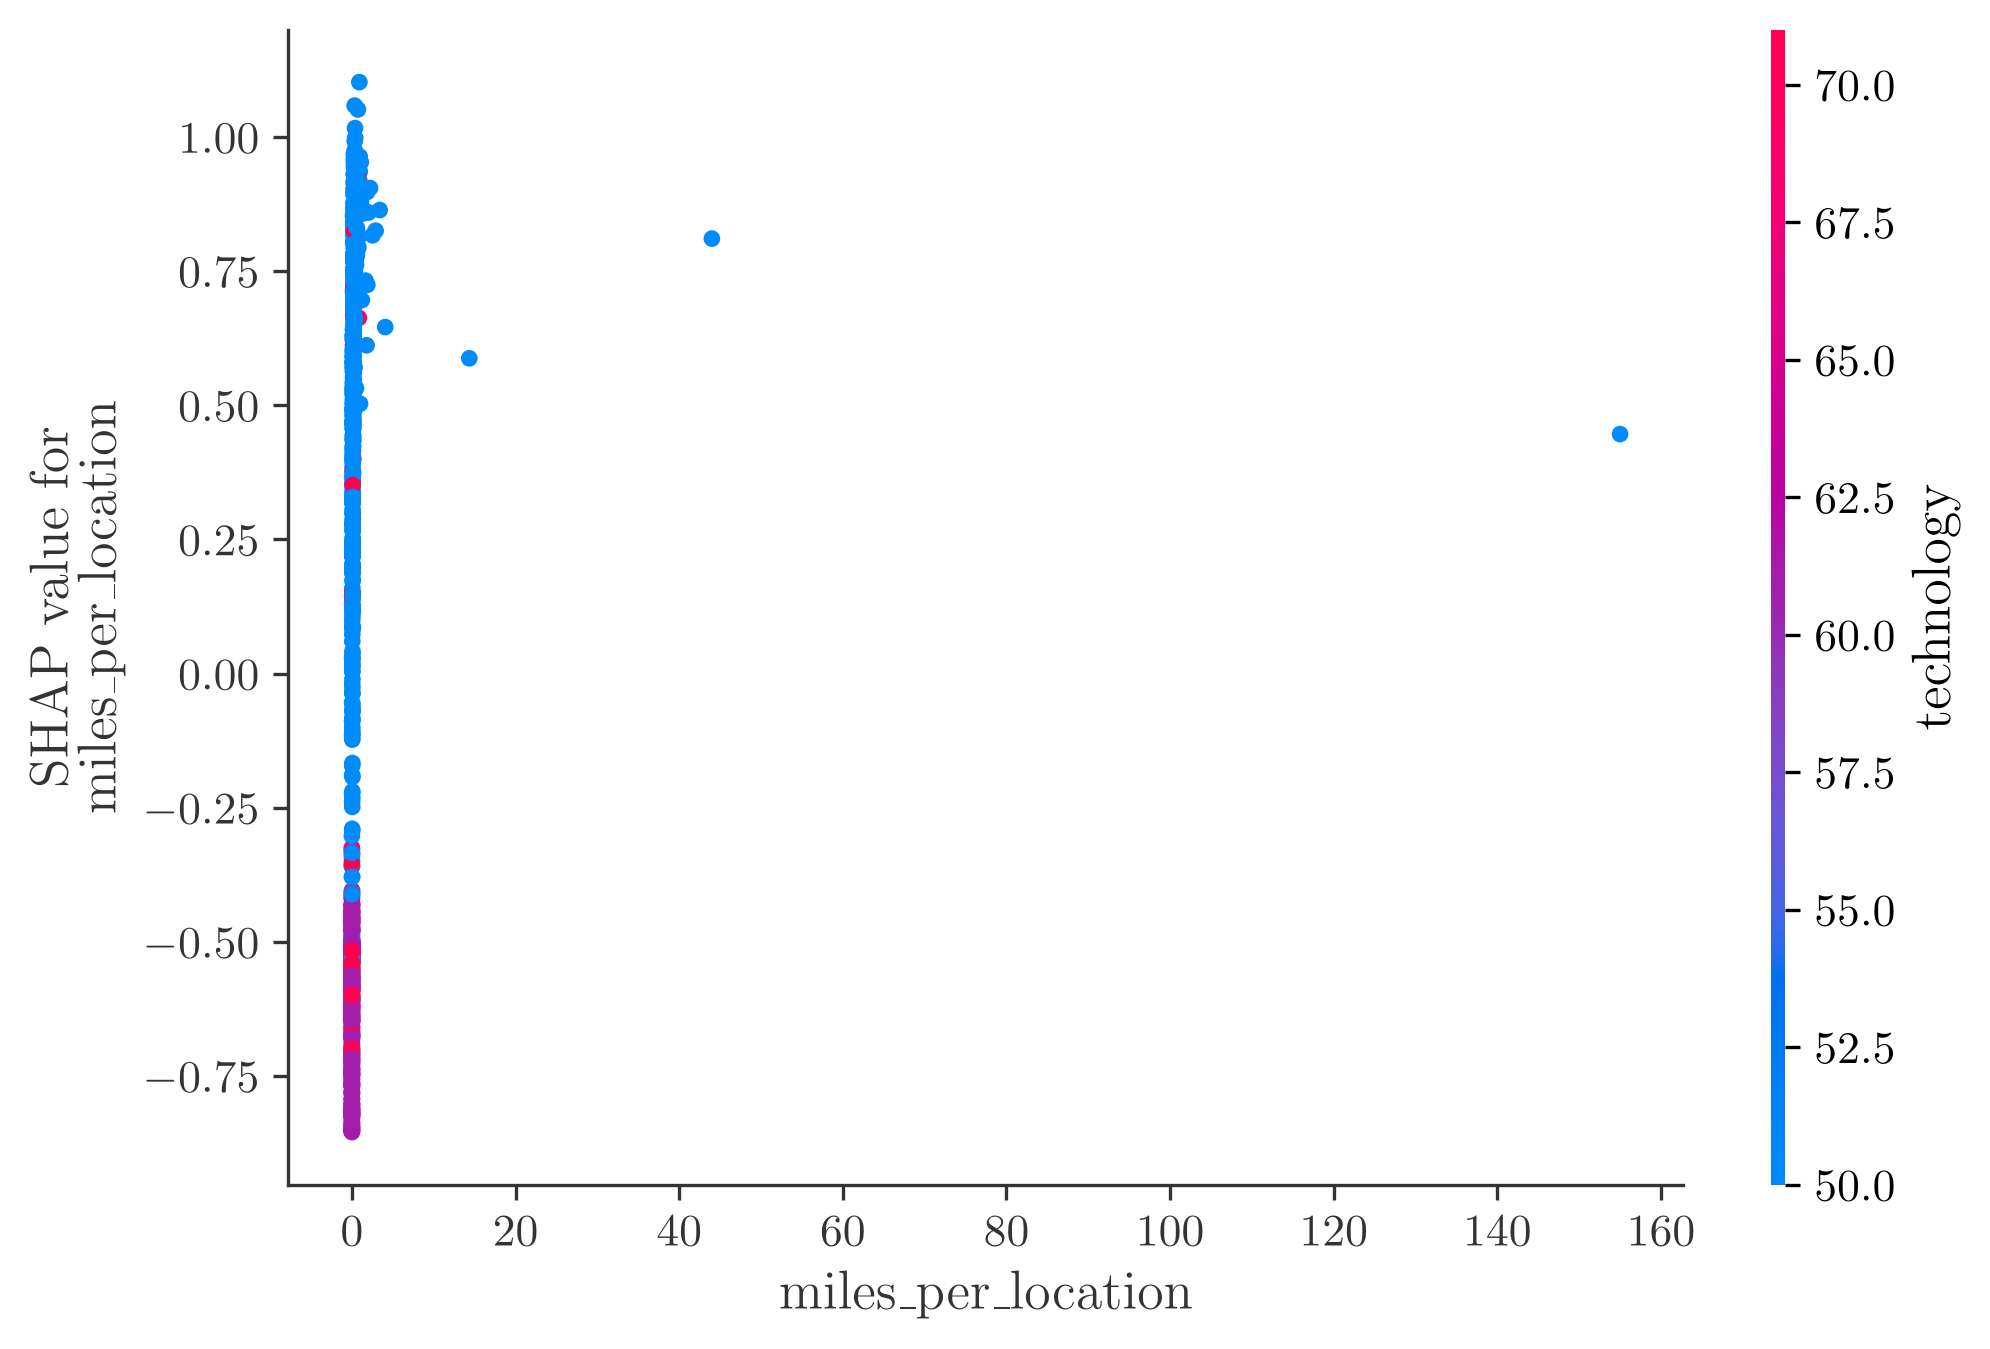

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test.sample(1000, random_state=42))

# this shows miles_per_location on x-axis, SHAP value on y-axis,
# colored by technology — you'll see separate curves per tech type
shap.dependence_plot(
    'miles_per_location', shap_values,
    X_test.sample(1000, random_state=42),
    interaction_index='technology'
)

# Spearman

In [50]:
import scipy.stats as st
spearman_res = {}
for i in [
    "miles_per_location", "jobs_per_location",
    "RRS_wmean", "ARS_wmean", "state_population",
    "HOUDEN_RUR_wmean","HOUDEN_COU_wmean", 
    "POPDEN_COU_wmean","topography_z_wmean", 
    "water_area_pct_wmean", "poverty_rate_wmean",
    "frac_competitor_present_qualifying",
    "frac_competitor_present_qualifying_no_sat",
    "frac_present_at_location",
    "frac_wireless_competitor_present",
    "frac_wireless_competitor_present_qualifying",
    "frac_wired_competitor_present",
    "frac_wired_competitor_present_qualifying",
    "frac_fiber_competitor_present",
    "frac_fiber_competitor_present_qualifying",
    "frac_cable_competitor_present",
    "frac_cable_competitor_present_qualifying",
    "frac_sat_competitor_present_qualifying",
    "frac_sat_only_competitor_qualifying"
    ]:
    df = df_full.copy()
    df.dropna(subset=[i, 'funding_per_location'], inplace=True)
    rho, p = st.spearmanr(df[i], df['funding_per_location'])
    spearman_res[i] = {"rho": rho, "p": p}

In [51]:
spearman_df = pd.DataFrame(spearman_res).T
spearman_df['abs_rho'] = abs(spearman_df.rho)

In [52]:
spearman_df.sort_values(by='abs_rho',ascending=False)

,rho,p,abs_rho
miles_per_location,0.738375,0.000000e+00,0.738375
frac_sat_competitor_present_qualifying,0.538092,0.000000e+00,0.538092
frac_sat_only_competitor_qualifying,0.513420,0.000000e+00,0.513420
frac_present_at_location,-0.449467,2.816710e-243,0.449467
frac_competitor_present_qualifying,0.433191,3.286881e-224,0.433191
jobs_per_location,0.387723,7.341656e-178,0.387723
frac_wireless_competitor_present_qualifying,0.106789,5.945018e-14,0.106789
RRS_wmean,0.069221,1.197686e-06,0.069221
frac_cable_competitor_present_qualifying,0.058889,3.584903e-05,0.058889
ARS_wmean,0.056679,7.050959e-05,0.056679


# Add distance

In [ ]:
# 1. Pull ALL served locations from NBM (any provider, qualifying speeds)
served_query = """
SELECT DISTINCT
    nbm.location_id,
    bsl.latitude,
    bsl.longitude
FROM `broadband-data.fcc_bdc.nbm_hive` nbm
JOIN `broadband-data.bsl_fabric.v7` bsl
    ON nbm.location_id = bsl.location_id
WHERE nbm.period = '2025_06'
    AND nbm.max_advertised_download_speed >= 100
    AND nbm.max_advertised_upload_speed >= 20
    AND bsl.latitude IS NOT NULL
    AND nbm.technology IN (40, 50, 60, 70, 71, 72)
"""

df_served_nbm = client.query(served_query).to_dataframe()

In [85]:
# 2. Pull BEAD locations (your prediction targets)
bead_query = """
SELECT
    loc.location_id,
    bsl.latitude,
    bsl.longitude
FROM `broadband-data.fp_approved.locations` loc
JOIN `broadband-data.bsl_fabric.v7` bsl
    ON loc.location_id = bsl.location_id
WHERE bsl.latitude IS NOT NULL
"""

df_bead = client.query(bead_query).to_dataframe()

In [87]:
# 3. Build BallTree from ALL NBM served locations
from sklearn.neighbors import BallTree
import numpy as np

EARTH_RADIUS_KM = 6371.0

served_rad = np.radians(df_served_nbm[['latitude', 'longitude']].values)
bead_rad = np.radians(df_bead[['latitude', 'longitude']].values)

print(f"Building BallTree from {len(df_served_nbm):,} NBM served locations...")
tree = BallTree(served_rad, metric='haversine')

print(f"Querying {len(df_bead):,} BEAD locations...")
distances, _ = tree.query(bead_rad, k=1)

df_bead['dist_nearest_served_km'] = distances.flatten() * EARTH_RADIUS_KM

# 4. Merge into enriched dataset
df_enriched = df_enriched.merge(
    df_bead[['location_id', 'dist_nearest_served_km']],
    on='location_id', how='left'
)

print(df_enriched['dist_nearest_served_km'].describe())

Building BallTree from 115,133,578 NBM served locations...
Querying 3,302,319 BEAD locations...
count    3.294884e+06
mean     6.825882e-04
std      3.268066e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.035176e+00
Name: dist_nearest_served_km, dtype: float64


In [89]:
df_enriched.to_csv('bead_enriched_dataset.csv', index=False)

In [90]:
comp_shares = df_enriched.groupby('project_id')[                                                 
      ['competitor_present', 'wired_competitor_present', 'fiber_competitor_present',             
       'cable_competitor_present', 'wireless_competitor_present',                                  
       'competitor_present_qualifying', 'wired_competitor_present_qualifying',
       'dist_nearest_served_km']                   
  ].mean().add_prefix('frac_').reset_index()      

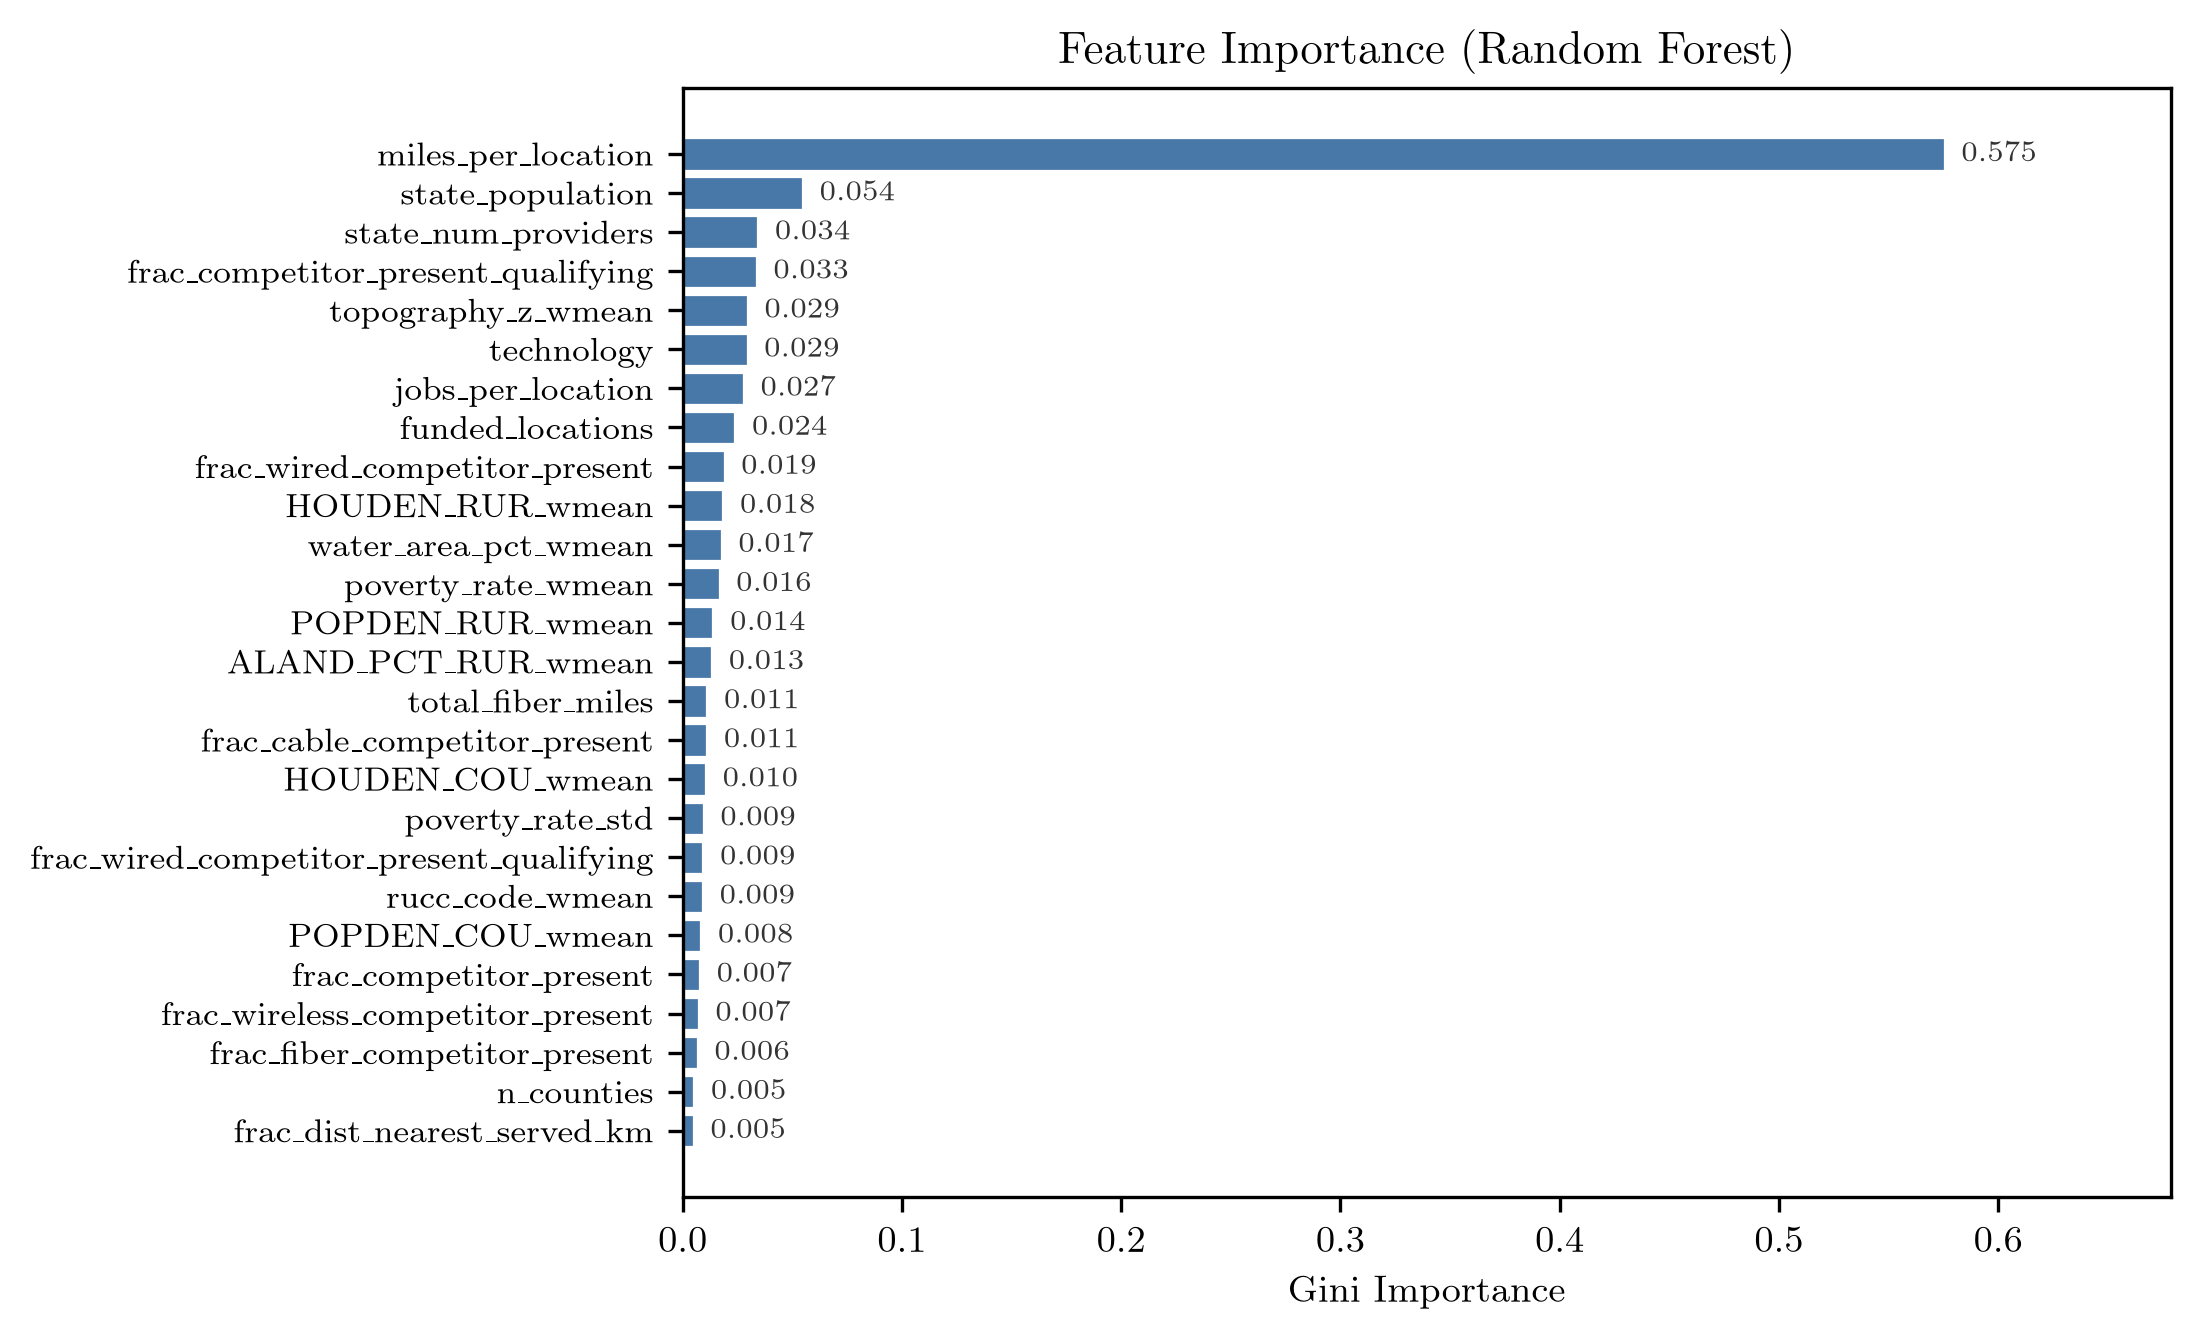

Saved: fig_feature_importance.pdf / .png


In [92]:
# ============================================================
# Figure 1: Feature Importance (Gini impurity-based)
# ============================================================
imp = pd.Series(rf.feature_importances_, index=feature_cols_full)
imp = imp.sort_values()

fig, ax = plt.subplots()
bars = ax.barh(imp.index, imp.values, color='#4878A8', edgecolor='white', linewidth=0.3)

# Annotate values
for bar, val in zip(bars, imp.values):
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7, color='#333')

ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importance (Random Forest)', weight='bold')
ax.set_xlim(0, imp.max() * 1.18)
ax.tick_params(axis='y', labelsize=8)

plt.savefig('fig_feature_importance.pdf')
plt.savefig('fig_feature_importance.png')
plt.show()
print('Saved: fig_feature_importance.pdf / .png')

# Add other competitor variables

In [373]:
additional_query = """SELECT 
location_id,
sat_competitor_present_qualifying,
sat_only_competitor_qualifying
FROM `broadband-data.fp_approved.competition_analysis`"""

df_additional_comp = client.query(additional_query).to_dataframe()

In [384]:
df_enriched = df_enriched.drop(columns = ['sat_only_competitor_qualifying_x',
'sat_competitor_present_qualifying',
'sat_only_competitor_qualifying_y'])

In [385]:
df_enriched = df_enriched.merge(
    df_additional_comp,
    on='location_id',
    how='left')

df_enriched.shape

(3294940, 77)

In [103]:
comp_shares = df_enriched_same_tech.groupby('project_id')[                                                 
      ['competitor_present', 'wired_competitor_present', 'fiber_competitor_present',             
       'cable_competitor_present', 'wireless_competitor_present',                                  
       'competitor_present_qualifying', 'wired_competitor_present_qualifying',
       'dist_nearest_served_km', 'same_tech_competitor_present', 'same_tech_competitor_present_qualifying']                   
  ].mean().add_prefix('frac_').reset_index()      

In [511]:
# Combine project-level df (state features) with weighted county aggregates and
# competition shares from df_enriched. One row per project, random 80/20 split.

df_full = (
    df
    .merge(proj_county_features, on='project_id', how='left')
    .merge(comp_shares, on='project_id', how='left')
)
print(f"df_full: {df_full.shape}, projects with any county match: "
      f"{df_full['n_counties'].notna().sum():,}")

county_wmean_cols = [c for c in df_full.columns if c.endswith('_wmean')]
comp_share_cols   = [c for c in df_full.columns if c.startswith('frac_')]

feature_cols_full = (
    ['miles_per_location', 'jobs_per_location', 'total_fiber_miles',
     'funded_locations', 'technology',
     'state_population', 'state_num_providers',
     'n_counties', 'poverty_rate_std']
    + county_wmean_cols
    + comp_share_cols
)

X = df_full[feature_cols_full].fillna(df_full[feature_cols_full].median(numeric_only=True))
y = df_full['log_funding']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# log-scale metric
r2_log = r2_score(y_test, y_pred)

# dollar-scale with Duan smearing (correct back-transform bias)
train_resid = y_train - rf.predict(X_train)
smear = float(np.mean(np.exp(train_resid)))
y_test_dollar = np.expm1(y_test)
y_pred_dollar = np.expm1(y_pred) * smear
rmse = np.sqrt(mean_squared_error(y_test_dollar, y_pred_dollar))
mae  = mean_absolute_error(y_test_dollar, y_pred_dollar)

# 5-fold CV (plain KFold — each project is one row, no group leakage possible)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)

print(f"\n{'='*70}")
print(f"Project-level RF: state + project + county wmeans + comp shares")
print(f"Features ({X.shape[1]}): {feature_cols_full}")
print(f"Projects:              {X.shape[0]:,}")
print(f"Train / test:          {len(X_train):,} / {len(X_test):,}")
print(f"Test R² (log-scale):   {r2_log:.4f}")
print(f"Smearing factor:       {smear:.4f}")
print(f"Test RMSE ($, smeared):{rmse:>10,.0f}")
print(f"Test MAE  ($, smeared):{mae:>10,.0f}")
print(f"5-fold CV R²:          {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"{'='*70}")

results['project_level_full'] = {
    'test_r2_log': r2_log, 'test_rmse': rmse, 'test_mae': mae,
    'smear': smear, 'cv_r2_mean': cv_r2.mean(), 'cv_r2_std': cv_r2.std(),
    'model': rf, 'features': feature_cols_full,
}

df_full: (5228, 41), projects with any county match: 5,175

Project-level RF: state + project + county wmeans + comp shares
Features (33): ['miles_per_location', 'jobs_per_location', 'total_fiber_miles', 'funded_locations', 'technology', 'state_population', 'state_num_providers', 'n_counties', 'poverty_rate_std', 'poverty_rate_wmean', 'rucc_code_wmean', 'topography_z_wmean', 'water_area_pct_wmean', 'POPDEN_COU_wmean', 'HOUDEN_COU_wmean', 'POPDEN_RUR_wmean', 'HOUDEN_RUR_wmean', 'RRS_wmean', 'ARS_wmean', 'ALAND_PCT_RUR_wmean', 'frac_competitor_present_qualifying', 'frac_competitor_present_qualifying_no_sat', 'frac_present_at_location', 'frac_wireless_competitor_present', 'frac_wireless_competitor_present_qualifying', 'frac_wired_competitor_present', 'frac_wired_competitor_present_qualifying', 'frac_fiber_competitor_present', 'frac_fiber_competitor_present_qualifying', 'frac_cable_competitor_present', 'frac_cable_competitor_present_qualifying', 'frac_sat_competitor_present_qualifying', 'f

In [ ]:
df_full.same_

,project_id,state,bead_support,estimated_miles_aerial_fiber,estimated_miles_buried_fiber,estimated_jobs,funded_locations,technology,state_num_providers,state_population,...,n_counties,poverty_rate_std,frac_competitor_present,frac_wired_competitor_present,frac_fiber_competitor_present,frac_cable_competitor_present,frac_wireless_competitor_present,frac_competitor_present_qualifying,frac_wired_competitor_present_qualifying,frac_dist_nearest_served_km
0,CM61-BEAD-CO-App-000273,CO,807905.97,12.0,0.0,0.0,161,50.0,156,5807299,...,1.0,NaN,1.0,0.729032,0.000000,0.0,1.0,1.000000,0.000000,0.0
1,CM61-BEAD-CO-App-000294,CO,960514.13,10.0,3.0,32.0,74,50.0,156,5807299,...,2.0,0.024843,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0
2,CM61-BEAD-CO-App-000300,CO,324976.34,4.0,0.0,0.0,76,50.0,156,5807299,...,1.0,NaN,1.0,0.371429,0.000000,0.0,1.0,1.000000,0.000000,0.0
3,CM61-BEAD-CO-App-000305,CO,1128153.68,21.0,0.0,0.0,355,50.0,156,5807299,...,1.0,NaN,1.0,0.525862,0.000000,0.0,1.0,1.000000,0.000000,0.0
4,CM61-BEAD-CO-App-000330,CO,609683.78,9.0,0.0,0.0,184,50.0,156,5807299,...,1.0,NaN,1.0,0.797814,0.000000,0.0,1.0,1.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4957,CM61-BEAD-WA-26-96212-376,WA,1314000.00,0.0,0.0,0.0,821,61.0,143,7693493,...,1.0,NaN,1.0,0.366580,0.000000,0.0,1.0,0.182642,0.000000,0.0
4958,CM61-BEAD-WA-26-96212-377,WA,171600.00,0.0,0.0,0.0,286,61.0,143,7693493,...,1.0,NaN,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0
4959,CM61-BEAD-WA-26-96212-378,WA,17056.00,0.0,0.0,0.0,11,61.0,143,7693493,...,1.0,NaN,1.0,0.818182,0.000000,0.0,1.0,1.000000,0.000000,0.0
4960,CM61-BEAD-WA-26-96212-220,WA,252600.00,0.0,0.0,0.0,421,61.0,143,7693493,...,1.0,NaN,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0


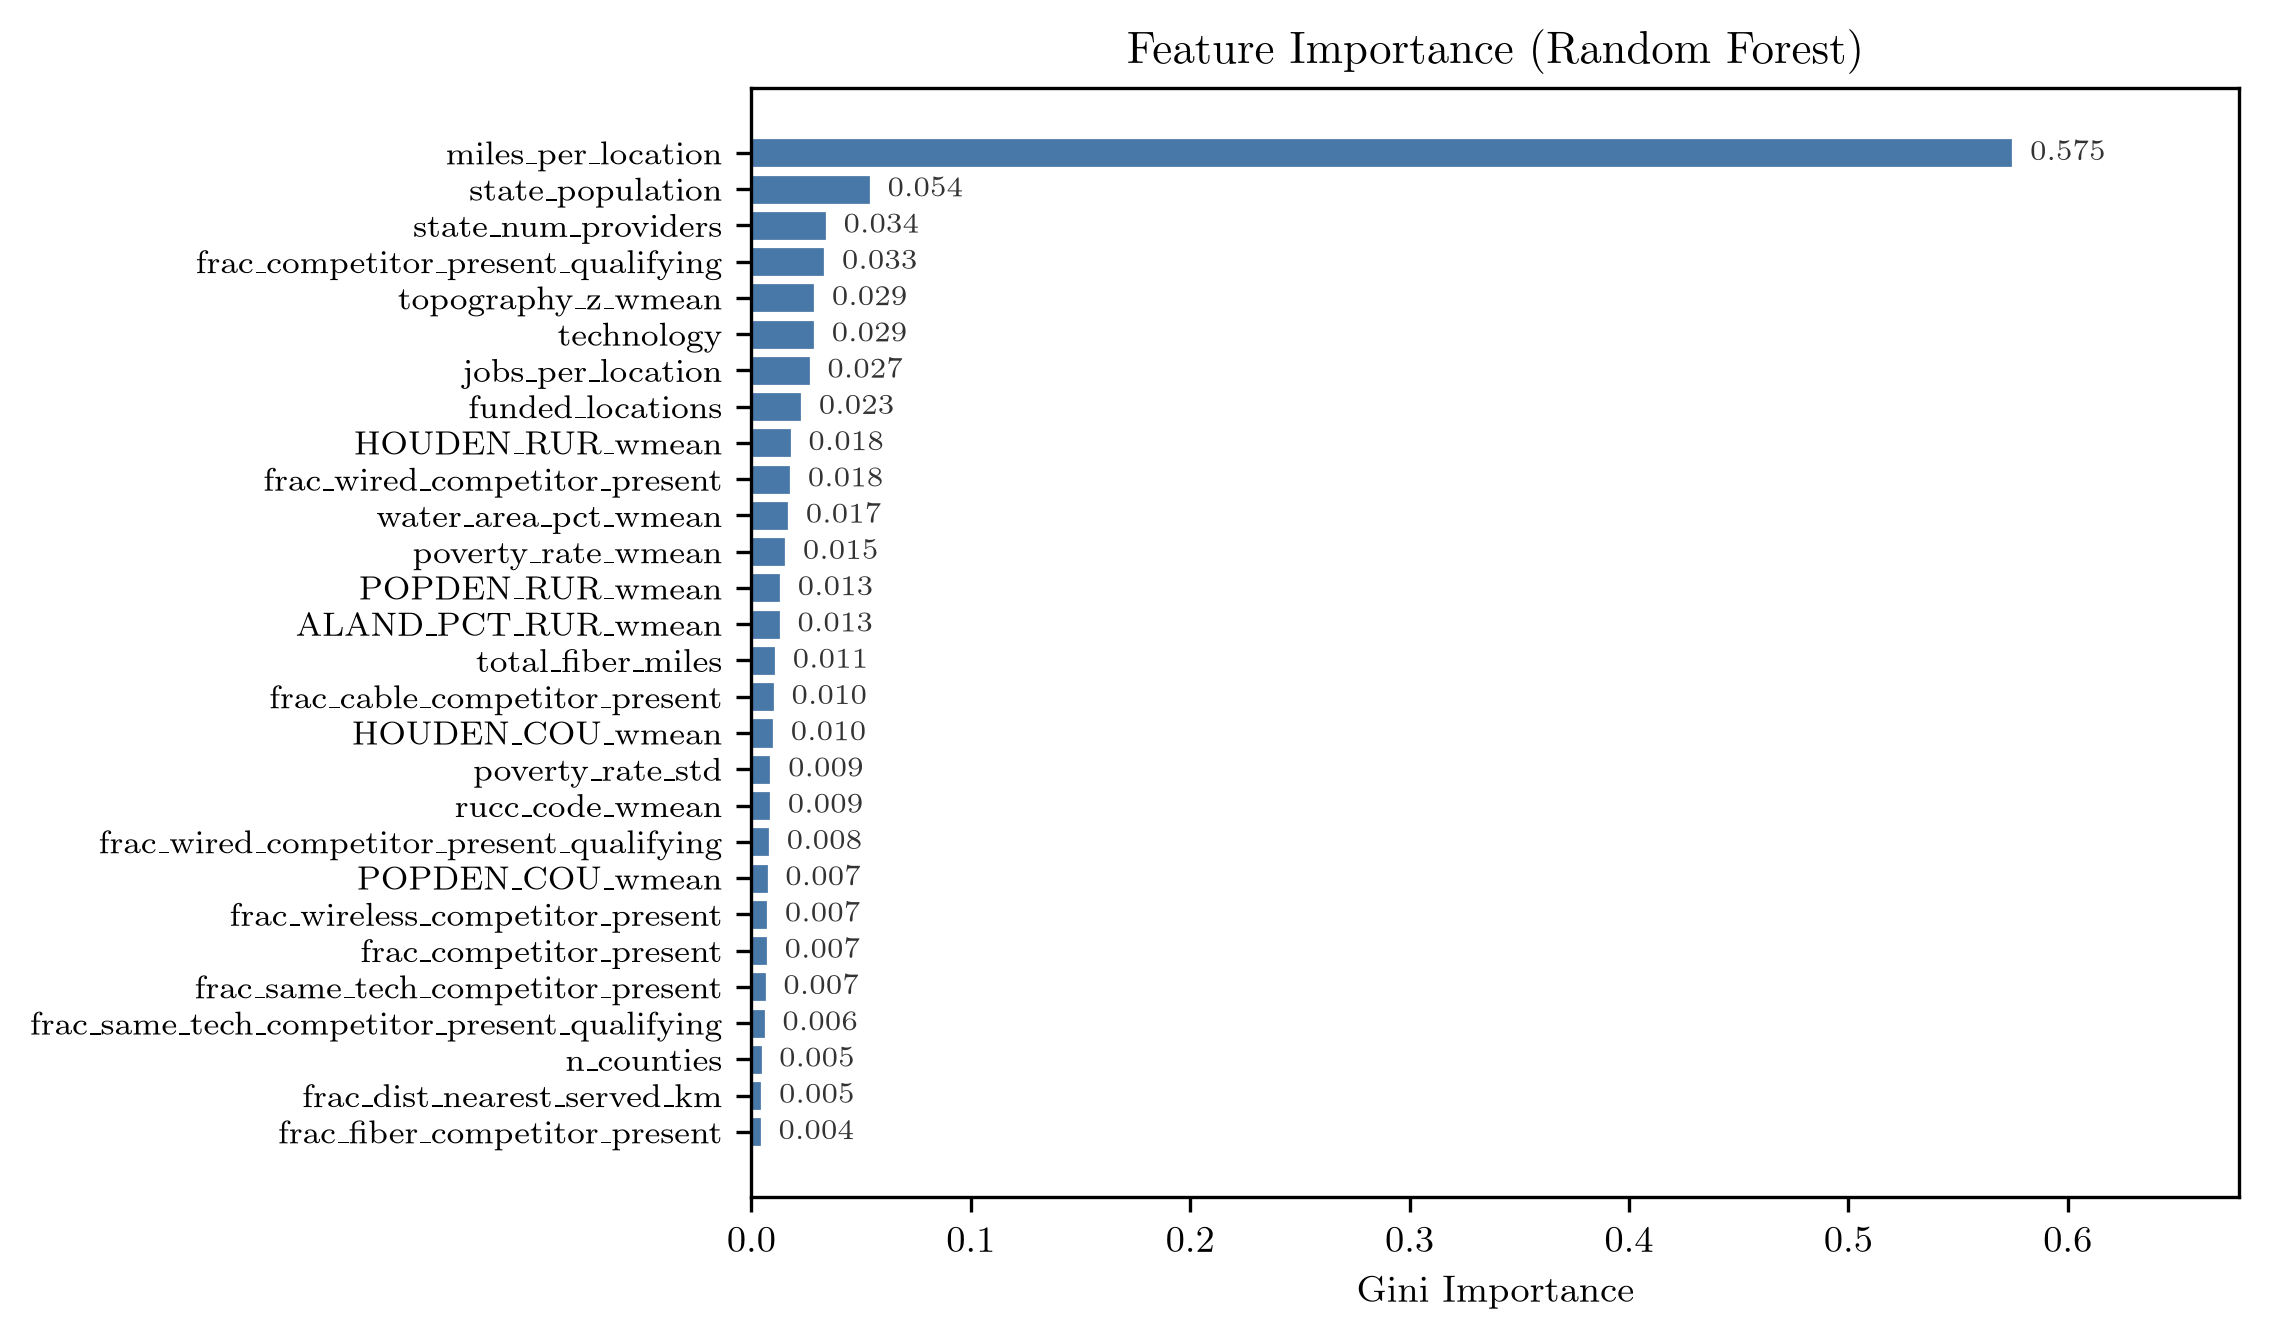

Saved: fig_feature_importance.pdf / .png


In [106]:
# ============================================================
# Figure 1: Feature Importance (Gini impurity-based)
# ============================================================
imp = pd.Series(rf.feature_importances_, index=feature_cols_full)
imp = imp.sort_values()

fig, ax = plt.subplots()
bars = ax.barh(imp.index, imp.values, color='#4878A8', edgecolor='white', linewidth=0.3)

# Annotate values
for bar, val in zip(bars, imp.values):
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7, color='#333')

ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importance (Random Forest)', weight='bold')
ax.set_xlim(0, imp.max() * 1.18)
ax.tick_params(axis='y', labelsize=8)

plt.savefig('fig_feature_importance.pdf')
plt.savefig('fig_feature_importance.png')
plt.show()
print('Saved: fig_feature_importance.pdf / .png')

# Final Check

In [53]:
def eval(X, y, test_name):
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
    )

    rf = RandomForestRegressor(
        n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    # log-scale metric
    r2_log = r2_score(y_test, y_pred)

    # dollar-scale with Duan smearing (correct back-transform bias)
    train_resid = y_train - rf.predict(X_train)
    smear = float(np.mean(np.exp(train_resid)))
    y_test_dollar = np.expm1(y_test)
    y_pred_dollar = np.expm1(y_pred) * smear
    rmse = np.sqrt(mean_squared_error(y_test_dollar, y_pred_dollar))
    mae  = mean_absolute_error(y_test_dollar, y_pred_dollar)

    # 5-fold CV (plain KFold — each project is one row, no group leakage possible)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(rf, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)

    print(f"\n{'='*70}")
    print(f"Project-level RF: state + project + county wmeans + comp shares")
    print(f"Features ({X.shape[1]}): {X_train.columns.to_list()}")
    print(f"Projects:              {X.shape[0]:,}")
    print(f"Train / test:          {len(X_train):,} / {len(X_test):,}")
    print(f"Test R² (log-scale):   {r2_log:.4f}")
    print(f"Smearing factor:       {smear:.4f}")
    print(f"Test RMSE ($, smeared):{rmse:>10,.0f}")
    print(f"Test MAE  ($, smeared):{mae:>10,.0f}")
    print(f"5-fold CV R²:          {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"{'='*70}")

    results[test_name] = {
        'test_r2_log': r2_log, 'test_rmse': rmse, 'test_mae': mae,
        'smear': smear, 'cv_r2_mean': cv_r2.mean(), 'cv_r2_std': cv_r2.std(),
        'model': rf, 'features': X_train.columns.to_list(),
    }

In [54]:
# Infrastructure cost
infra = ['miles_per_location', 'jobs_per_location', 'total_fiber_miles', 'funded_locations']

# Technology
tech = ['technology']

# Geography / NTIA cost factors
geo = ['rucc_code_wmean','topography_z_wmean', 'ARS_wmean', 'RRS_wmean', 'HOUDEN_RUR_wmean', 'state_population', 'poverty_rate_wmean']
geo_improved = ['topography_z_wmean', 'RRS_wmean', 'HOUDEN_RUR_wmean']

# Awardee advantage (not competition — self-presence)
awardee = ['frac_present_at_location']

# State context
state = ['state_population', 'state_num_providers']

# Actual competition
competition = ['frac_sat_only_competitor_qualifying']

# Run two models: without and with competition
features_base = infra + tech + geo + awardee + state
features_base_improved = infra + tech + geo_improved + awardee + state
features_full = features_base + competition
features_comp = infra + tech + geo + state + competition
features_top10 = ['miles_per_location',
 'frac_sat_only_competitor_qualifying',
 'frac_present_at_location',
 'state_population',
 'technology',
 'state_num_providers',
 'jobs_per_location',
 'topography_z_wmean',
 'HOUDEN_RUR_wmean',
 'funded_locations',
 'RRS_wmean',
 'total_fiber_miles']

feature_cols_full = (
    ['miles_per_location', 'jobs_per_location', 'total_fiber_miles',
     'funded_locations', 'technology',
     'state_population', 'state_num_providers',
     'n_counties', 'poverty_rate_std']
    + county_wmean_cols
    + comp_share_cols
)

X = df_full[feature_cols_full].fillna(df_full[feature_cols_full].median(numeric_only=True))
y = df_full['log_funding']

results['ntia'] = eval(X[geo], y, "NTIA only")
results['base'] = eval(X[features_base], y, "All except competition")
results['base_imprvoed'] = eval(X[features_base_improved], y, "features_base_improved")
results['only_comp'] = eval(X[features_comp], y, "Only competition")
results['with_comp'] = eval(X[features_full], y, "Adding non-satellite competition")
results['top_10'] = eval(X[features_top10], y, "Adding non-satellite competition")


Project-level RF: state + project + county wmeans + comp shares
Features (7): ['rucc_code_wmean', 'topography_z_wmean', 'ARS_wmean', 'RRS_wmean', 'HOUDEN_RUR_wmean', 'state_population', 'poverty_rate_wmean']
Projects:              4,966
Train / test:          3,476 / 1,490
Test R² (log-scale):   0.1447
Smearing factor:       1.1955
Test RMSE ($, smeared):     3,467
Test MAE  ($, smeared):     2,426
5-fold CV R²:          0.1663 ± 0.0312

Project-level RF: state + project + county wmeans + comp shares
Features (15): ['miles_per_location', 'jobs_per_location', 'total_fiber_miles', 'funded_locations', 'technology', 'rucc_code_wmean', 'topography_z_wmean', 'ARS_wmean', 'RRS_wmean', 'HOUDEN_RUR_wmean', 'state_population', 'poverty_rate_wmean', 'frac_present_at_location', 'state_population', 'state_num_providers']
Projects:              4,966
Train / test:          3,476 / 1,490
Test R² (log-scale):   0.7589
Smearing factor:       1.0239
Test RMSE ($, smeared):     2,211
Test MAE  ($, smear

In [55]:
a = ['miles_per_location', 'jobs_per_location', 'total_fiber_miles', 'funded_locations', 'technology', 'topography_z_wmean', 'RRS_wmean', 'HOUDEN_RUR_wmean', 'frac_present_at_location', 'state_population', 'state_num_providers']
b = ['miles_per_location', 'frac_sat_only_competitor_qualifying', 'frac_present_at_location', 'state_population', 'technology', 'state_num_providers', 'jobs_per_location', 'topography_z_wmean', 'HOUDEN_RUR_wmean', 'funded_locations']

print([c for c in a if c not in b])

['total_fiber_miles', 'RRS_wmean']


In [56]:
results['base'] = eval(X[features_base], y, "All except competition")


Project-level RF: state + project + county wmeans + comp shares
Features (15): ['miles_per_location', 'jobs_per_location', 'total_fiber_miles', 'funded_locations', 'technology', 'rucc_code_wmean', 'topography_z_wmean', 'ARS_wmean', 'RRS_wmean', 'HOUDEN_RUR_wmean', 'state_population', 'poverty_rate_wmean', 'frac_present_at_location', 'state_population', 'state_num_providers']
Projects:              4,966
Train / test:          3,476 / 1,490
Test R² (log-scale):   0.7589
Smearing factor:       1.0239
Test RMSE ($, smeared):     2,211
Test MAE  ($, smeared):     1,269
5-fold CV R²:          0.7730 ± 0.0167



Project-level RF: state + project + county wmeans + comp shares
Features (11): ['miles_per_location', 'jobs_per_location', 'total_fiber_miles', 'funded_locations', 'technology', 'topography_z_wmean', 'RRS_wmean', 'HOUDEN_RUR_wmean', 'frac_present_at_location', 'state_population', 'state_num_providers']
Projects:              4,966
Train / test:          3,476 / 1,490
Test R² (log-scale):   0.7677
Smearing factor:       1.0245
Test RMSE ($, smeared):     2,181
Test MAE  ($, smeared):     1,253
5-fold CV R²:          0.7748 ± 0.0182


Text(0.97, 0.08, '$R^2 = 0.7677$')

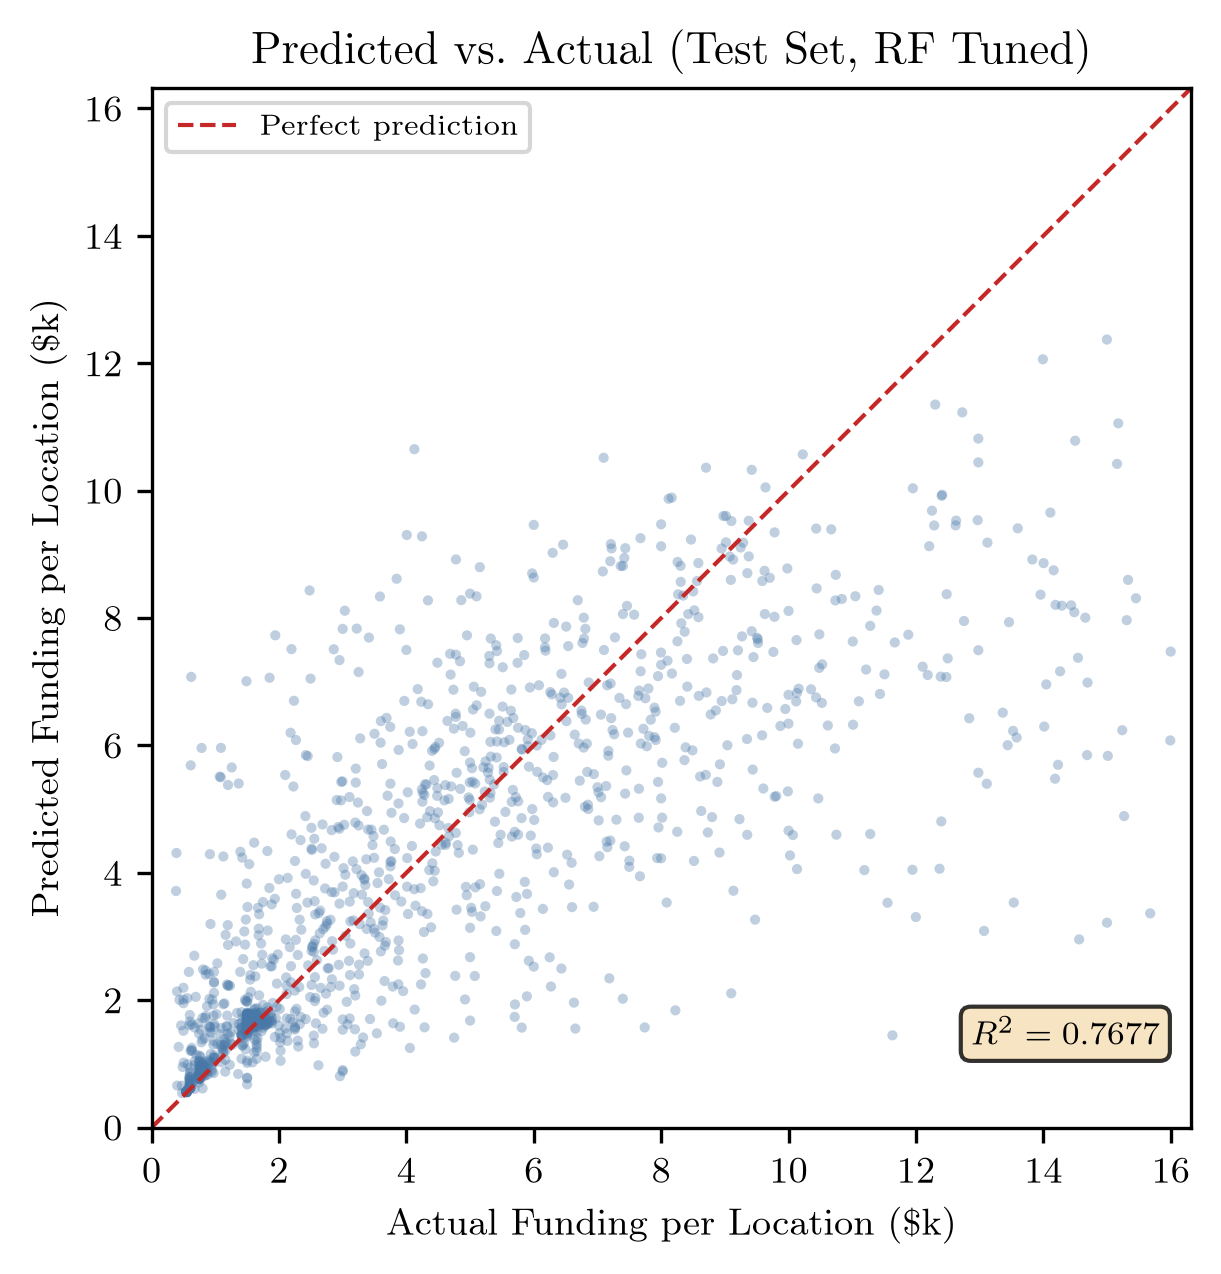

In [ ]:
features = ['miles_per_location', 'jobs_per_location', 'total_fiber_miles', 'funded_locations', 'technology', 'topography_z_wmean', 'RRS_wmean', 'HOUDEN_RUR_wmean', 'frac_present_at_location', 'state_population', 'state_num_providers']

X_train, X_test, y_train, y_test = train_test_split(
    X[features], y, test_size=0.3, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# log-scale metric
r2_log = r2_score(y_test, y_pred)

# dollar-scale with Duan smearing (correct back-transform bias)
train_resid = y_train - rf.predict(X_train)
smear = float(np.mean(np.exp(train_resid)))
y_test_dollar = np.expm1(y_test)
y_pred_dollar = np.expm1(y_pred) * smear
rmse = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(y_pred)))
mae = mean_absolute_error(np.expm1(y_te), np.expm1(y_pred))

# 5-fold CV (plain KFold — each project is one row, no group leakage possible)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)

print(f"\n{'='*70}")
print(f"Project-level RF: state + project + county wmeans + comp shares")
print(f"Features ({X_train.shape[1]}): {X_train.columns.to_list()}")
print(f"Projects:              {X.shape[0]:,}")
print(f"Train / test:          {len(X_train):,} / {len(X_test):,}")
print(f"Test R² (log-scale):   {r2_log:.4f}")
print(f"Smearing factor:       {smear:.4f}")
print(f"Test RMSE ($, smeared):{rmse:>10,.0f}")
print(f"Test MAE  ($, smeared):{mae:>10,.0f}")
print(f"5-fold CV R²:          {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"{'='*70}")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(y_test_dollar / 1000, y_pred_dollar / 1000,
           s=6, alpha=0.35, color='#4878A8', edgecolors='none', rasterized=True)

lims = [0, max(y_test_dollar.max(), y_pred_dollar.max()) / 1000 * 1.02]
ax.plot(lims, lims, '--', color='#C62828', lw=1.0, label='Perfect prediction')

ax.set_xlabel('Actual Funding per Location (\\$k)' if HAS_LATEX else 'Actual Funding per Location ($k)')
ax.set_ylabel('Predicted Funding per Location (\\$k)' if HAS_LATEX else 'Predicted Funding per Location ($k)')
ax.set_title('Predicted vs.\\ Actual (Test Set, RF Tuned)' if HAS_LATEX else 'Predicted vs. Actual (Test Set, RF Tuned)', weight='bold')
ax.legend(fontsize=7, loc='upper left')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')

r2_label = f'$R^2 = {r2_log:.4f}$' if HAS_LATEX else f'R² = {r2_log:.4f}'
ax.text(0.97, 0.08, r2_label,
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

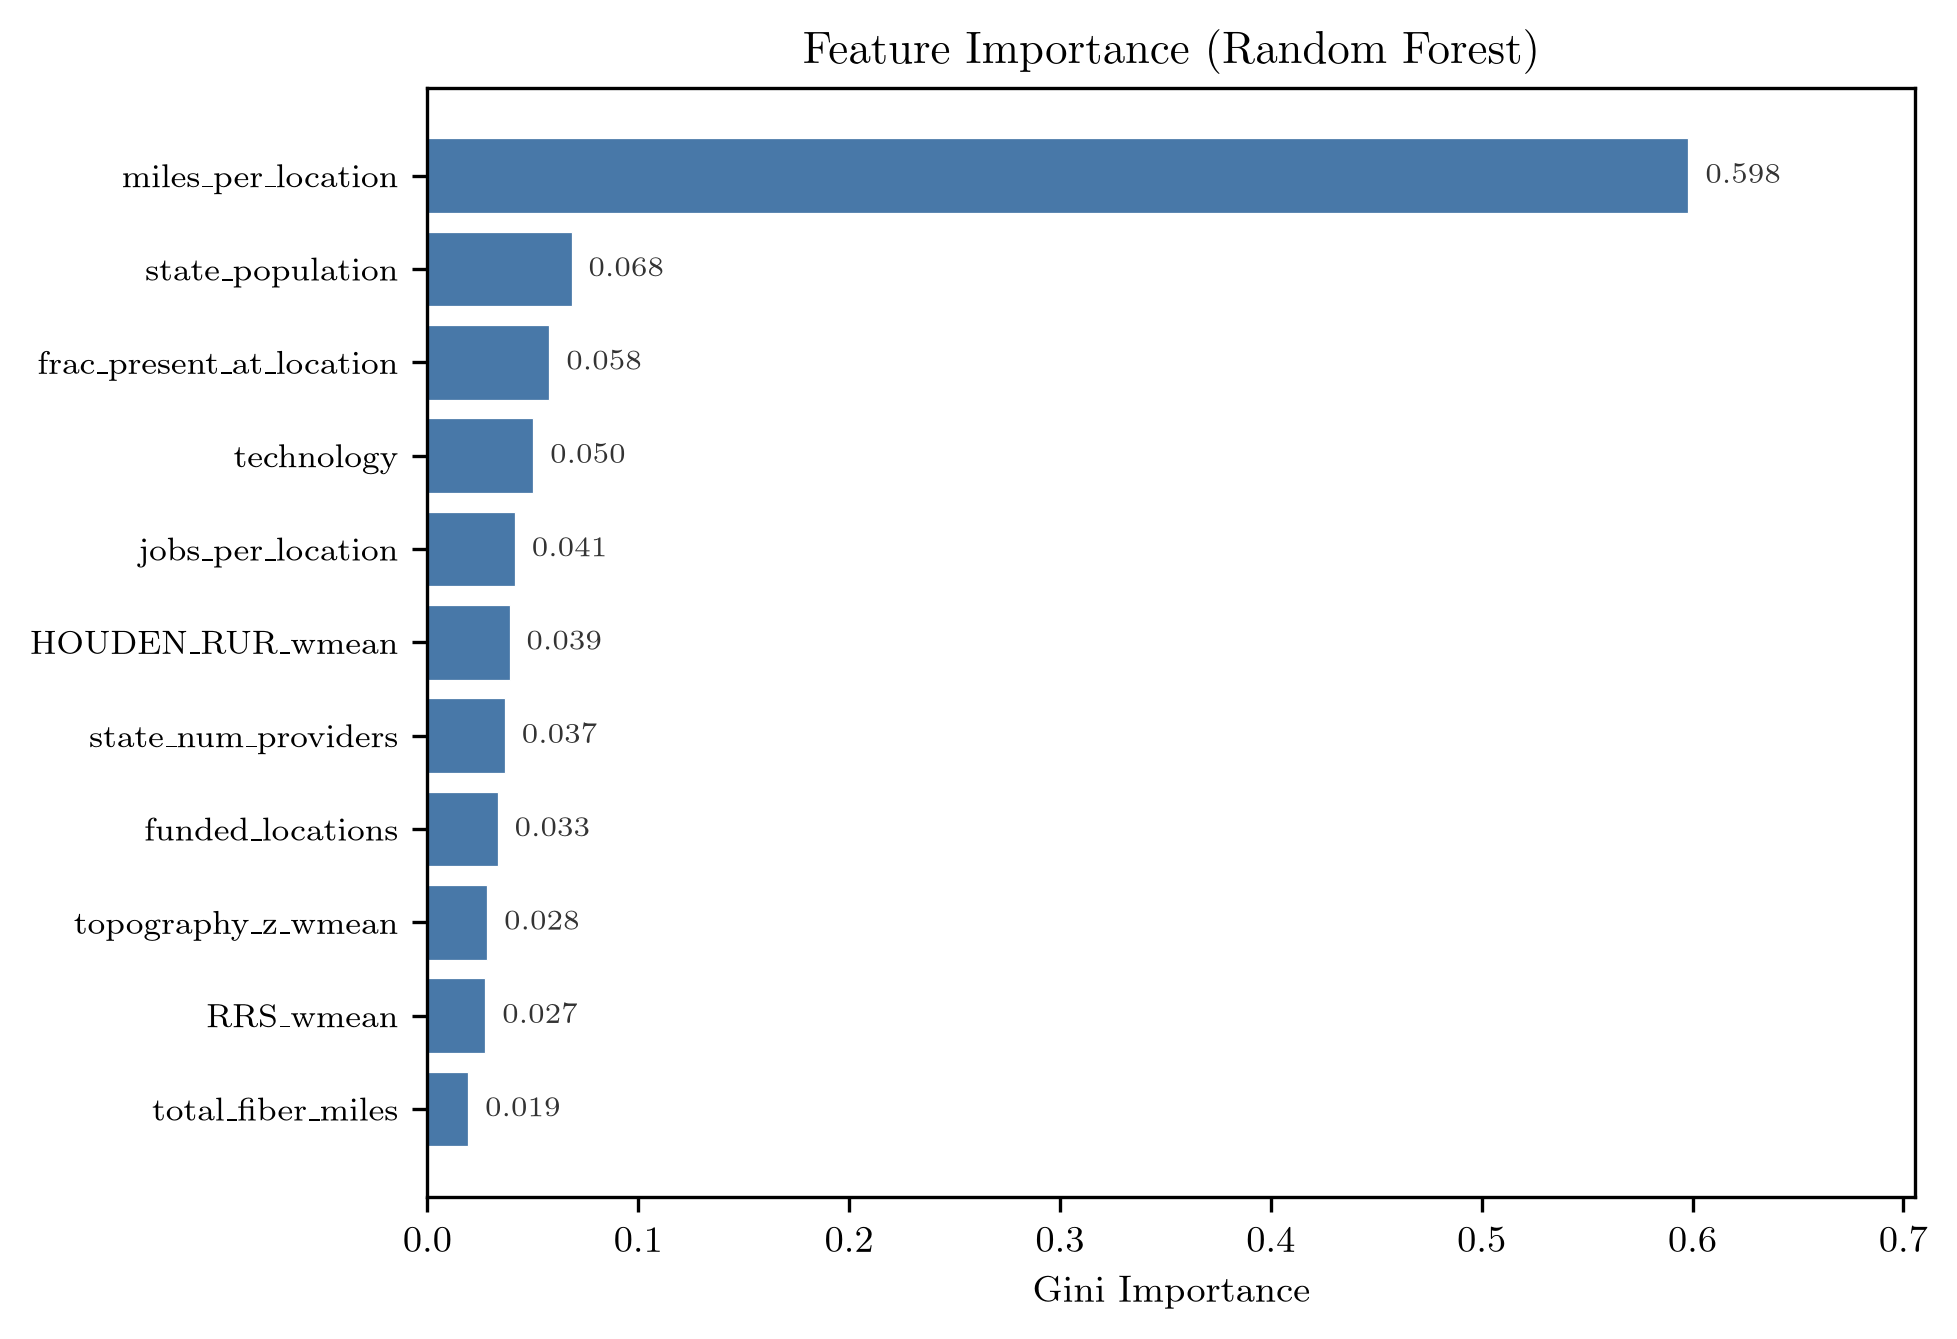

Saved: fig_feature_importance.pdf / .png


In [58]:
# ============================================================
# Figure 1: Feature Importance (Gini impurity-based)
# ============================================================
imp = pd.Series(rf.feature_importances_, index=features)
imp = imp.sort_values()

fig, ax = plt.subplots()
bars = ax.barh(imp.index, imp.values, color='#4878A8', edgecolor='white', linewidth=0.3)

# Annotate values
for bar, val in zip(bars, imp.values):
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7, color='#333')

ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importance (Random Forest)', weight='bold')
ax.set_xlim(0, imp.max() * 1.18)
ax.tick_params(axis='y', labelsize=8)

plt.savefig('fig_feature_importance.pdf')
plt.savefig('fig_feature_importance.png')
plt.show()
print('Saved: fig_feature_importance.pdf / .png')

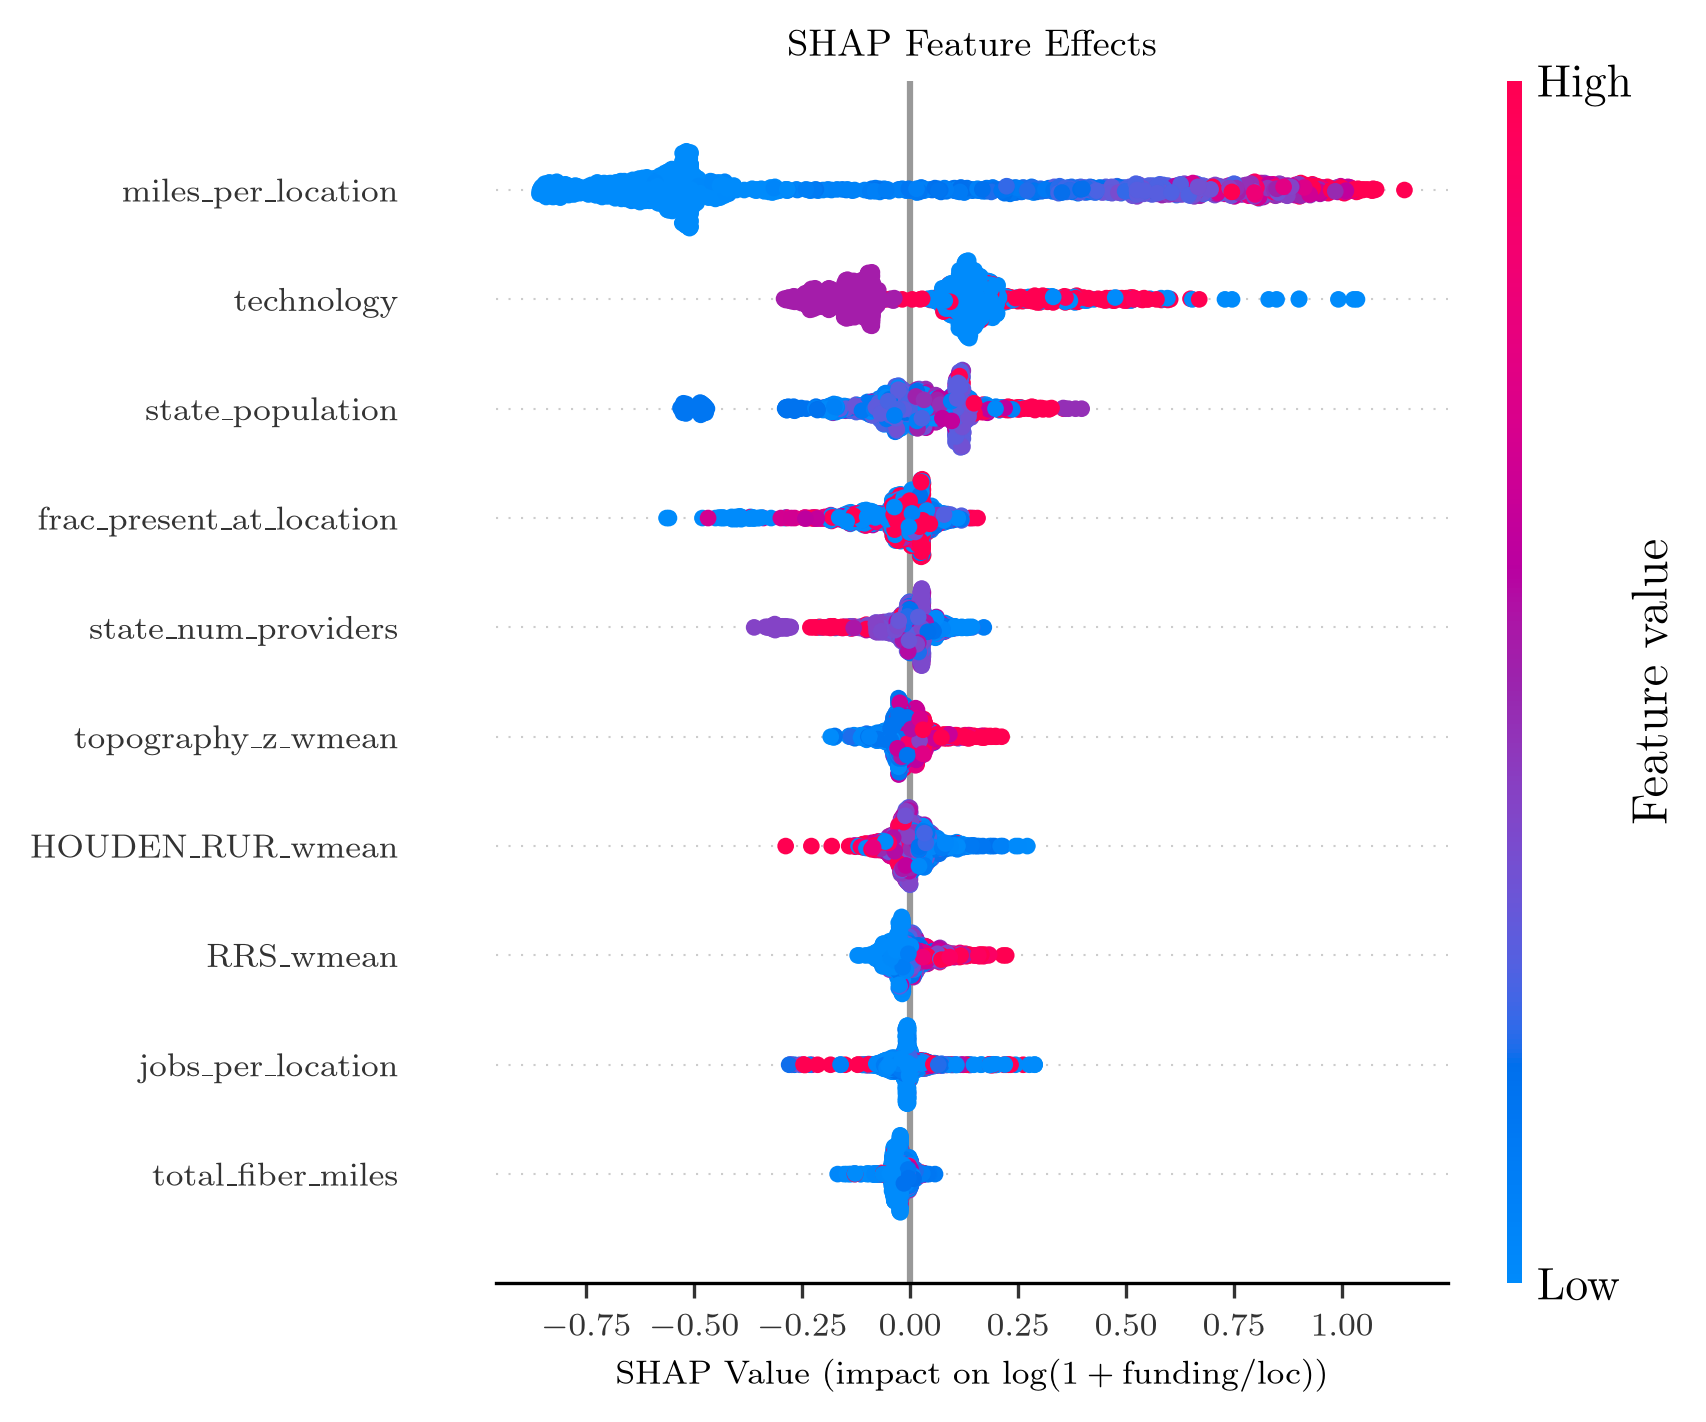

Saved: fig_shap_beeswarm.pdf / .png


In [59]:
# ============================================================
# Figure 2: SHAP Beeswarm Summary Plot
# ============================================================
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots()
shap.summary_plot(shap_values, X_test,
                  show=False, plot_size=None, max_display=10)
ax = plt.gca()
ax.set_xlabel('SHAP Value (impact on $\\log(1+\\mathrm{funding/loc})$)', fontsize=8)
ax.set_title('SHAP Feature Effects', weight='bold', fontsize=9)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)

plt.savefig('fig_shap_beeswarm.pdf')
plt.savefig('fig_shap_beeswarm.png')
plt.show()
print('Saved: fig_shap_beeswarm.pdf / .png')

In [62]:
tech_dummies = pd.get_dummies(df_enriched['awarded_technology'], prefix='tech', dtype=int)
X1 = pd.concat([tech_dummies, df_enriched], axis=1)

In [80]:
tech_codes = [40, 50, 61, 71]                                                                                           
                                                                                                                    
tech_flags = pd.DataFrame({                                                                                             
    f'tech_{c}': (df_enriched['awarded_technology'] == c).astype(int)                                                 
    for c in tech_codes                                                                                                 
})                                                                                                                    
tech_flags['project_id'] = df_enriched['project_id'].values
                                                                                                                        
tech_shares = (                             
    tech_flags                                                                                                          
    .groupby('project_id')[[f'tech_{c}' for c in tech_codes]]                                                         
    .mean()                                                                                                             
    .add_prefix('frac_')
    .reset_index()                                                                                                      
)                                                                                                                     
                                        
# Diagnostic: how many projects use more than one tech?
n_techs_per_project = df_enriched.groupby('project_id')['awarded_technology'].nunique()                                 
print("Projects by number of distinct technologies:")
print(n_techs_per_project.value_counts().sort_index())                                                                  
print(f"\nMulti-tech projects: {(n_techs_per_project > 1).sum()} "                                                    
    f"of {len(n_techs_per_project)} "                                                                                 
    f"({(n_techs_per_project > 1).mean() * 100:.1f}%)")
                                                                                                                        
tech_shares.head()                                                                                                      
                                                                                                                                            
# df_full = (                                                                                                             
#     df_full                                                                                                                
#     # .merge(proj_county_features, on='project_id', how='left')                                                           
#     # .merge(comp_shares,           on='project_id', how='left')                                                        
#     .merge(tech_shares,           on='project_id', how='left')   # <-- add
# )                                                                         
                                                                                            
tech_share_cols = [c for c in df_full.columns if c.startswith('frac_tech_')]
comp_share_cols = [c for c in df_full.columns if c.startswith('frac_')                                                  
                                            and c not in tech_share_cols]                                                                                                              
feature_cols_full = (                                                                                                   
    ['miles_per_location', 'jobs_per_location', 'total_fiber_miles',                                                    
    'funded_locations', 'technology',                                                                                               
    'state_population', 'state_num_providers',                                                                         
    'n_counties', 'poverty_rate_std']                                                                                
    + county_wmean_cols                     
    + comp_share_cols                                                                                                   
    + tech_share_cols                       
) 

Projects by number of distinct technologies:
awarded_technology
1    4888
2     280
3       7
Name: count, dtype: int64

Multi-tech projects: 287 of 5175 (5.5%)



Project-level RF: state + project + county wmeans + comp shares
Features (14): ['miles_per_location', 'jobs_per_location', 'total_fiber_miles', 'funded_locations', 'topography_z_wmean', 'RRS_wmean', 'HOUDEN_RUR_wmean', 'frac_present_at_location', 'state_population', 'state_num_providers', 'frac_tech_40', 'frac_tech_50', 'frac_tech_61', 'frac_tech_71']
Projects:              4,966
Train / test:          3,476 / 1,490
Test R² (log-scale):   0.7700
Smearing factor:       1.0250
Test RMSE ($, smeared):     2,175
Test MAE  ($, smeared):     1,255
5-fold CV R²:          0.7720 ± 0.0164


Text(0.97, 0.08, '$R^2 = 0.7700$')

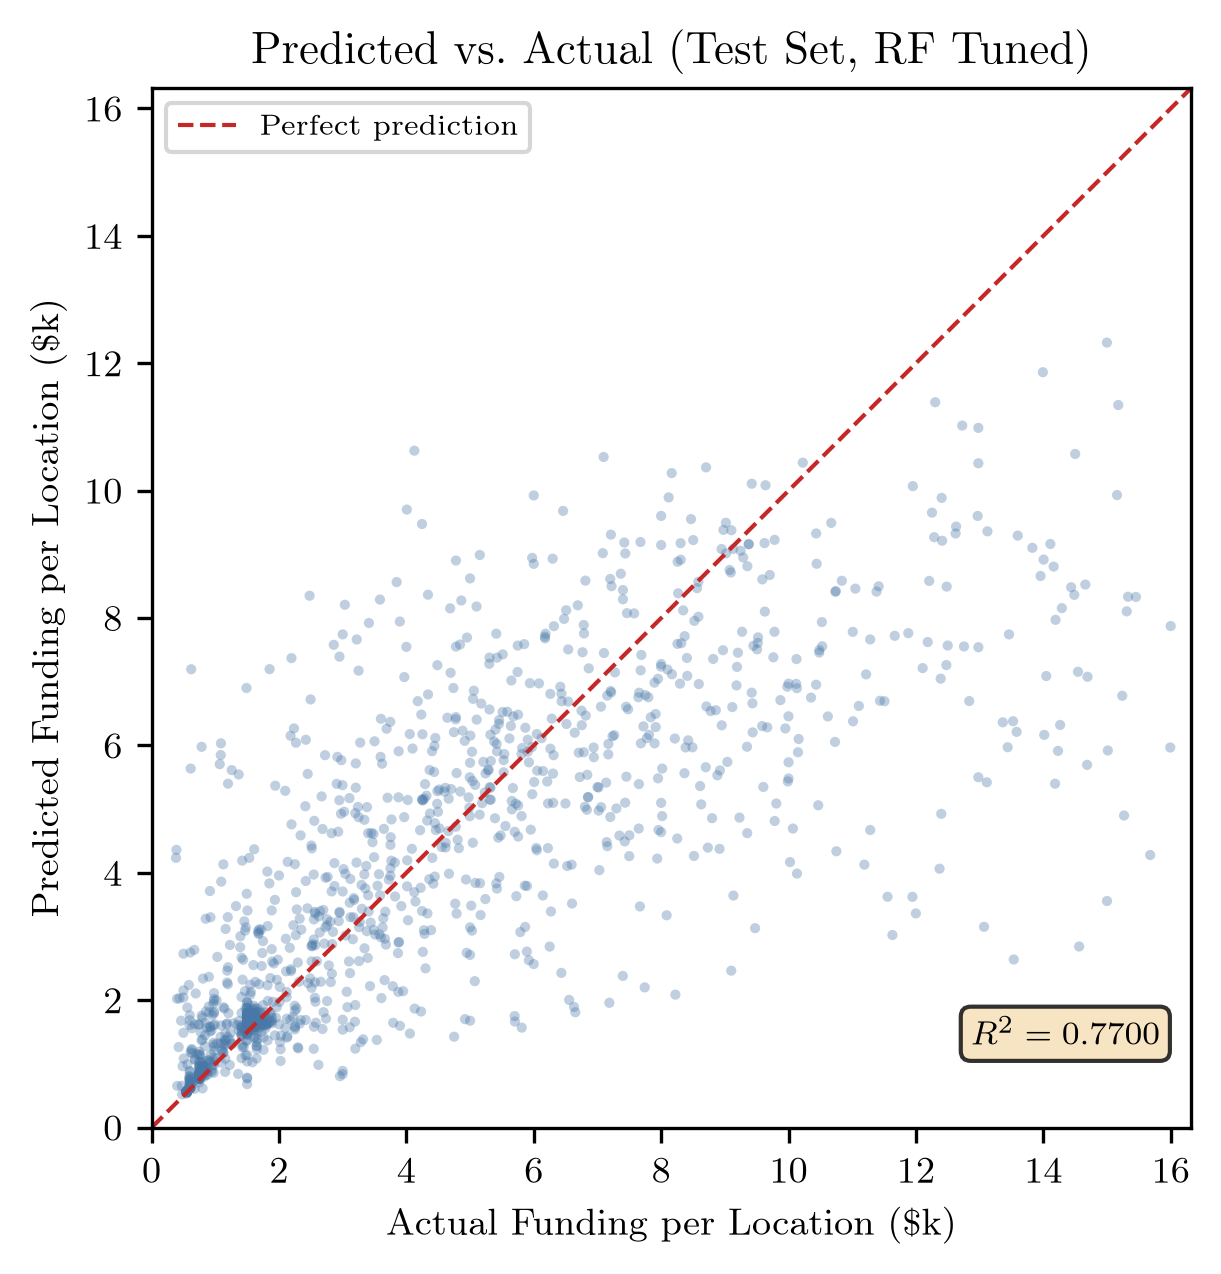

In [82]:
features = ['miles_per_location', 'jobs_per_location', 'total_fiber_miles', 'funded_locations', 'topography_z_wmean', 'RRS_wmean', 'HOUDEN_RUR_wmean', 'frac_present_at_location', 'state_population', 'state_num_providers'] + tech_share_cols

X = df_full[feature_cols_full].fillna(df_full[feature_cols_full].median(numeric_only=True))
y = df_full['log_funding']

X_train, X_test, y_train, y_test = train_test_split(
    X[features], y, test_size=0.3, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# log-scale metric
r2_log = r2_score(y_test, y_pred)

# dollar-scale with Duan smearing (correct back-transform bias)
train_resid = y_train - rf.predict(X_train)
smear = float(np.mean(np.exp(train_resid)))
y_test_dollar = np.expm1(y_test)
y_pred_dollar = np.expm1(y_pred) * smear
rmse = np.sqrt(mean_squared_error(y_test_dollar, y_pred_dollar))
mae  = mean_absolute_error(y_test_dollar, y_pred_dollar)

# 5-fold CV (plain KFold — each project is one row, no group leakage possible)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)

print(f"\n{'='*70}")
print(f"Project-level RF: state + project + county wmeans + comp shares")
print(f"Features ({X_train.shape[1]}): {X_train.columns.to_list()}")
print(f"Projects:              {X.shape[0]:,}")
print(f"Train / test:          {len(X_train):,} / {len(X_test):,}")
print(f"Test R² (log-scale):   {r2_log:.4f}")
print(f"Smearing factor:       {smear:.4f}")
print(f"Test RMSE ($, smeared):{rmse:>10,.0f}")
print(f"Test MAE  ($, smeared):{mae:>10,.0f}")
print(f"5-fold CV R²:          {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"{'='*70}")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(y_test_dollar / 1000, y_pred_dollar / 1000,
           s=6, alpha=0.35, color='#4878A8', edgecolors='none', rasterized=True)

lims = [0, max(y_test_dollar.max(), y_pred_dollar.max()) / 1000 * 1.02]
ax.plot(lims, lims, '--', color='#C62828', lw=1.0, label='Perfect prediction')

ax.set_xlabel('Actual Funding per Location (\\$k)' if HAS_LATEX else 'Actual Funding per Location ($k)')
ax.set_ylabel('Predicted Funding per Location (\\$k)' if HAS_LATEX else 'Predicted Funding per Location ($k)')
ax.set_title('Predicted vs.\\ Actual (Test Set, RF Tuned)' if HAS_LATEX else 'Predicted vs. Actual (Test Set, RF Tuned)', weight='bold')
ax.legend(fontsize=7, loc='upper left')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')

r2_label = f'$R^2 = {r2_log:.4f}$' if HAS_LATEX else f'R² = {r2_log:.4f}'
ax.text(0.97, 0.08, r2_label,
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

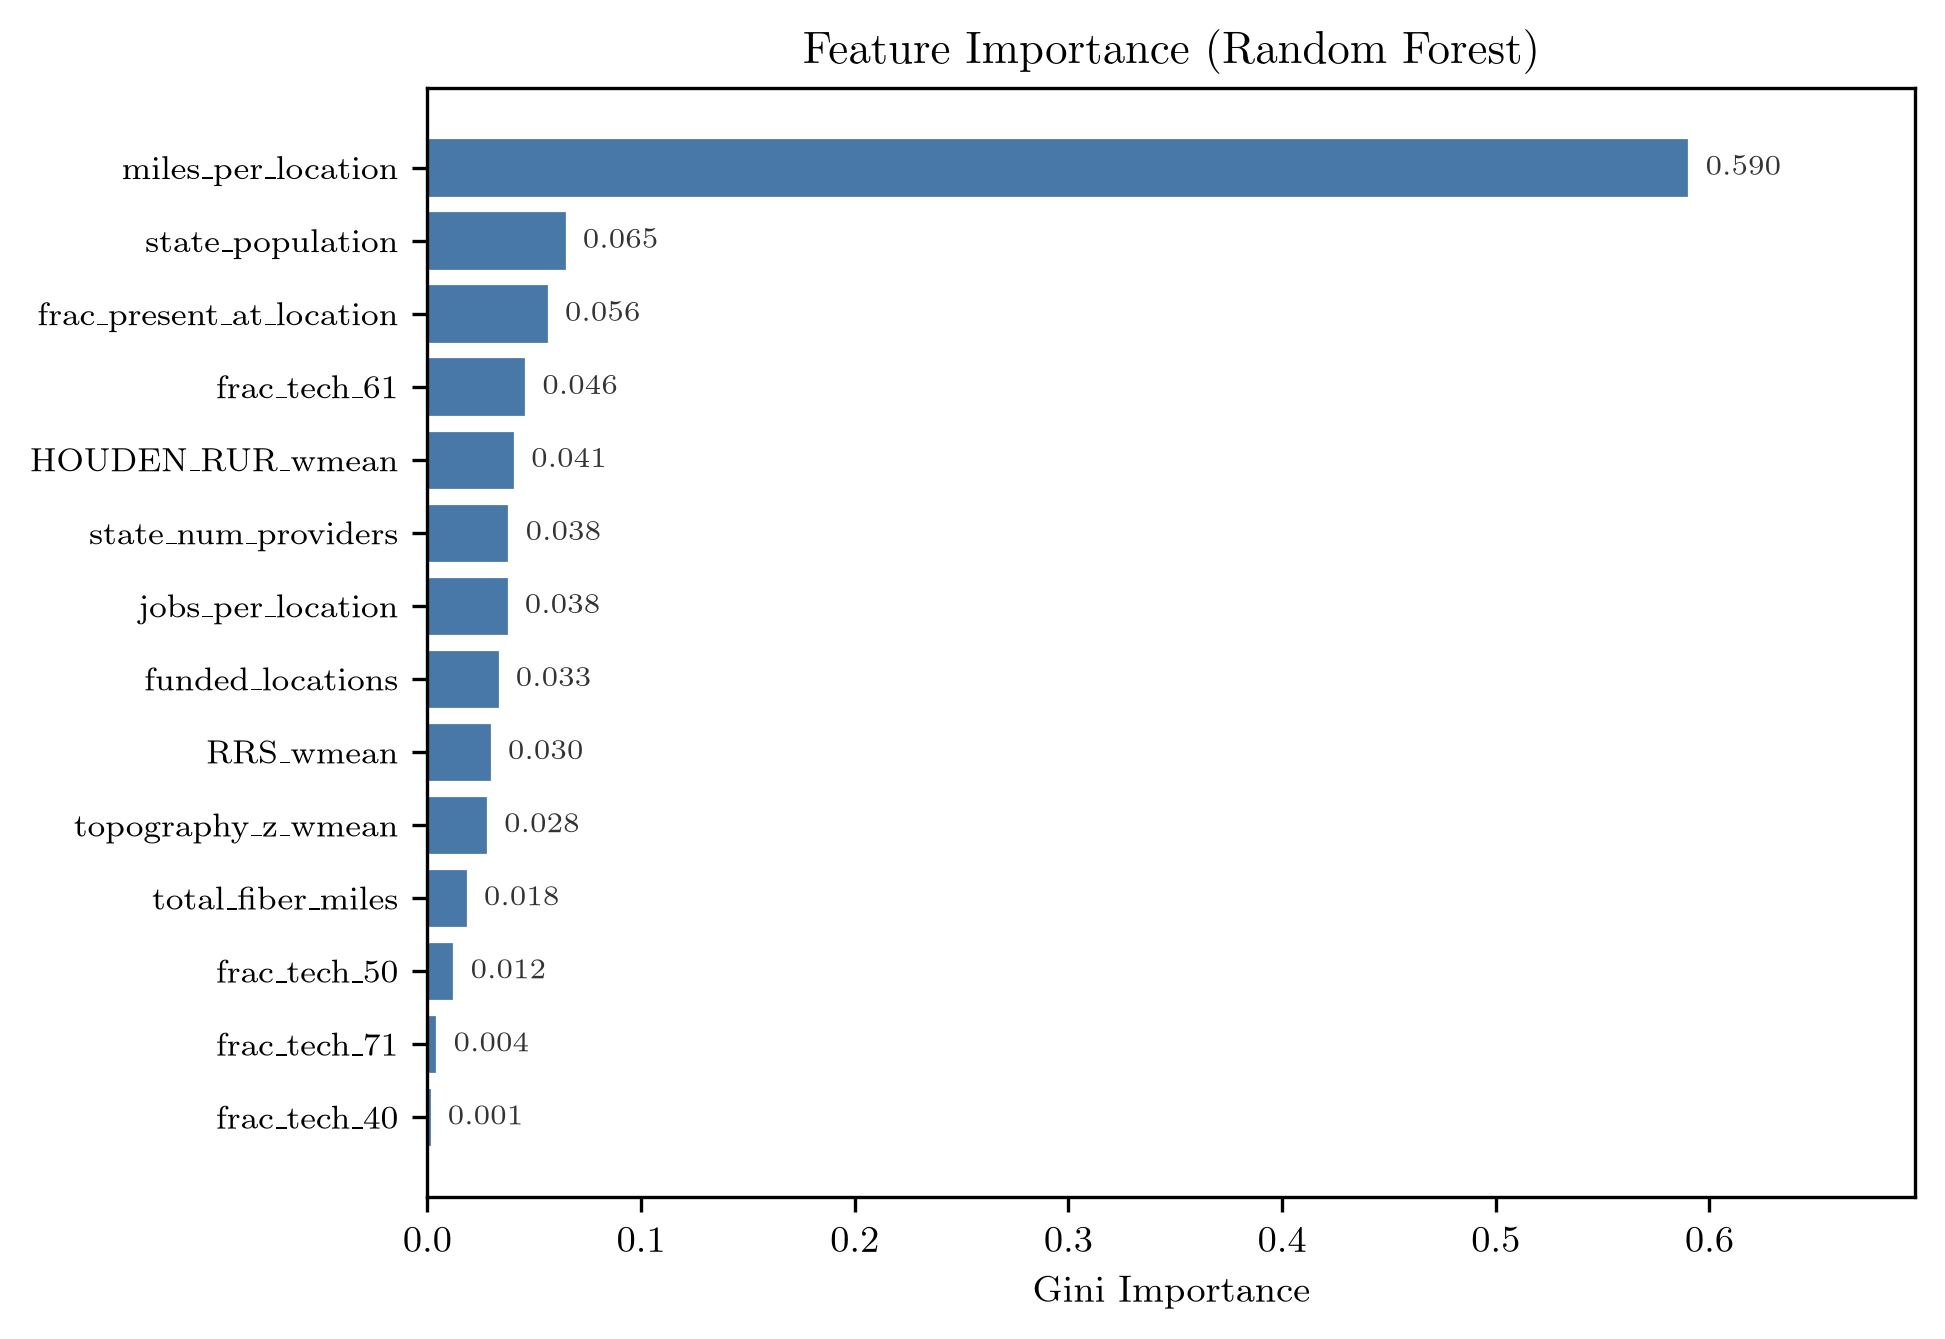

Saved: fig_feature_importance.pdf / .png


In [83]:
# ============================================================
# Figure 1: Feature Importance (Gini impurity-based)
# ============================================================
imp = pd.Series(rf.feature_importances_, index=features)
imp = imp.sort_values()

fig, ax = plt.subplots()
bars = ax.barh(imp.index, imp.values, color='#4878A8', edgecolor='white', linewidth=0.3)

# Annotate values
for bar, val in zip(bars, imp.values):
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7, color='#333')

ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importance (Random Forest)', weight='bold')
ax.set_xlim(0, imp.max() * 1.18)
ax.tick_params(axis='y', labelsize=8)

plt.savefig('fig_feature_importance.pdf')
plt.savefig('fig_feature_importance.png')
plt.show()
print('Saved: fig_feature_importance.pdf / .png')

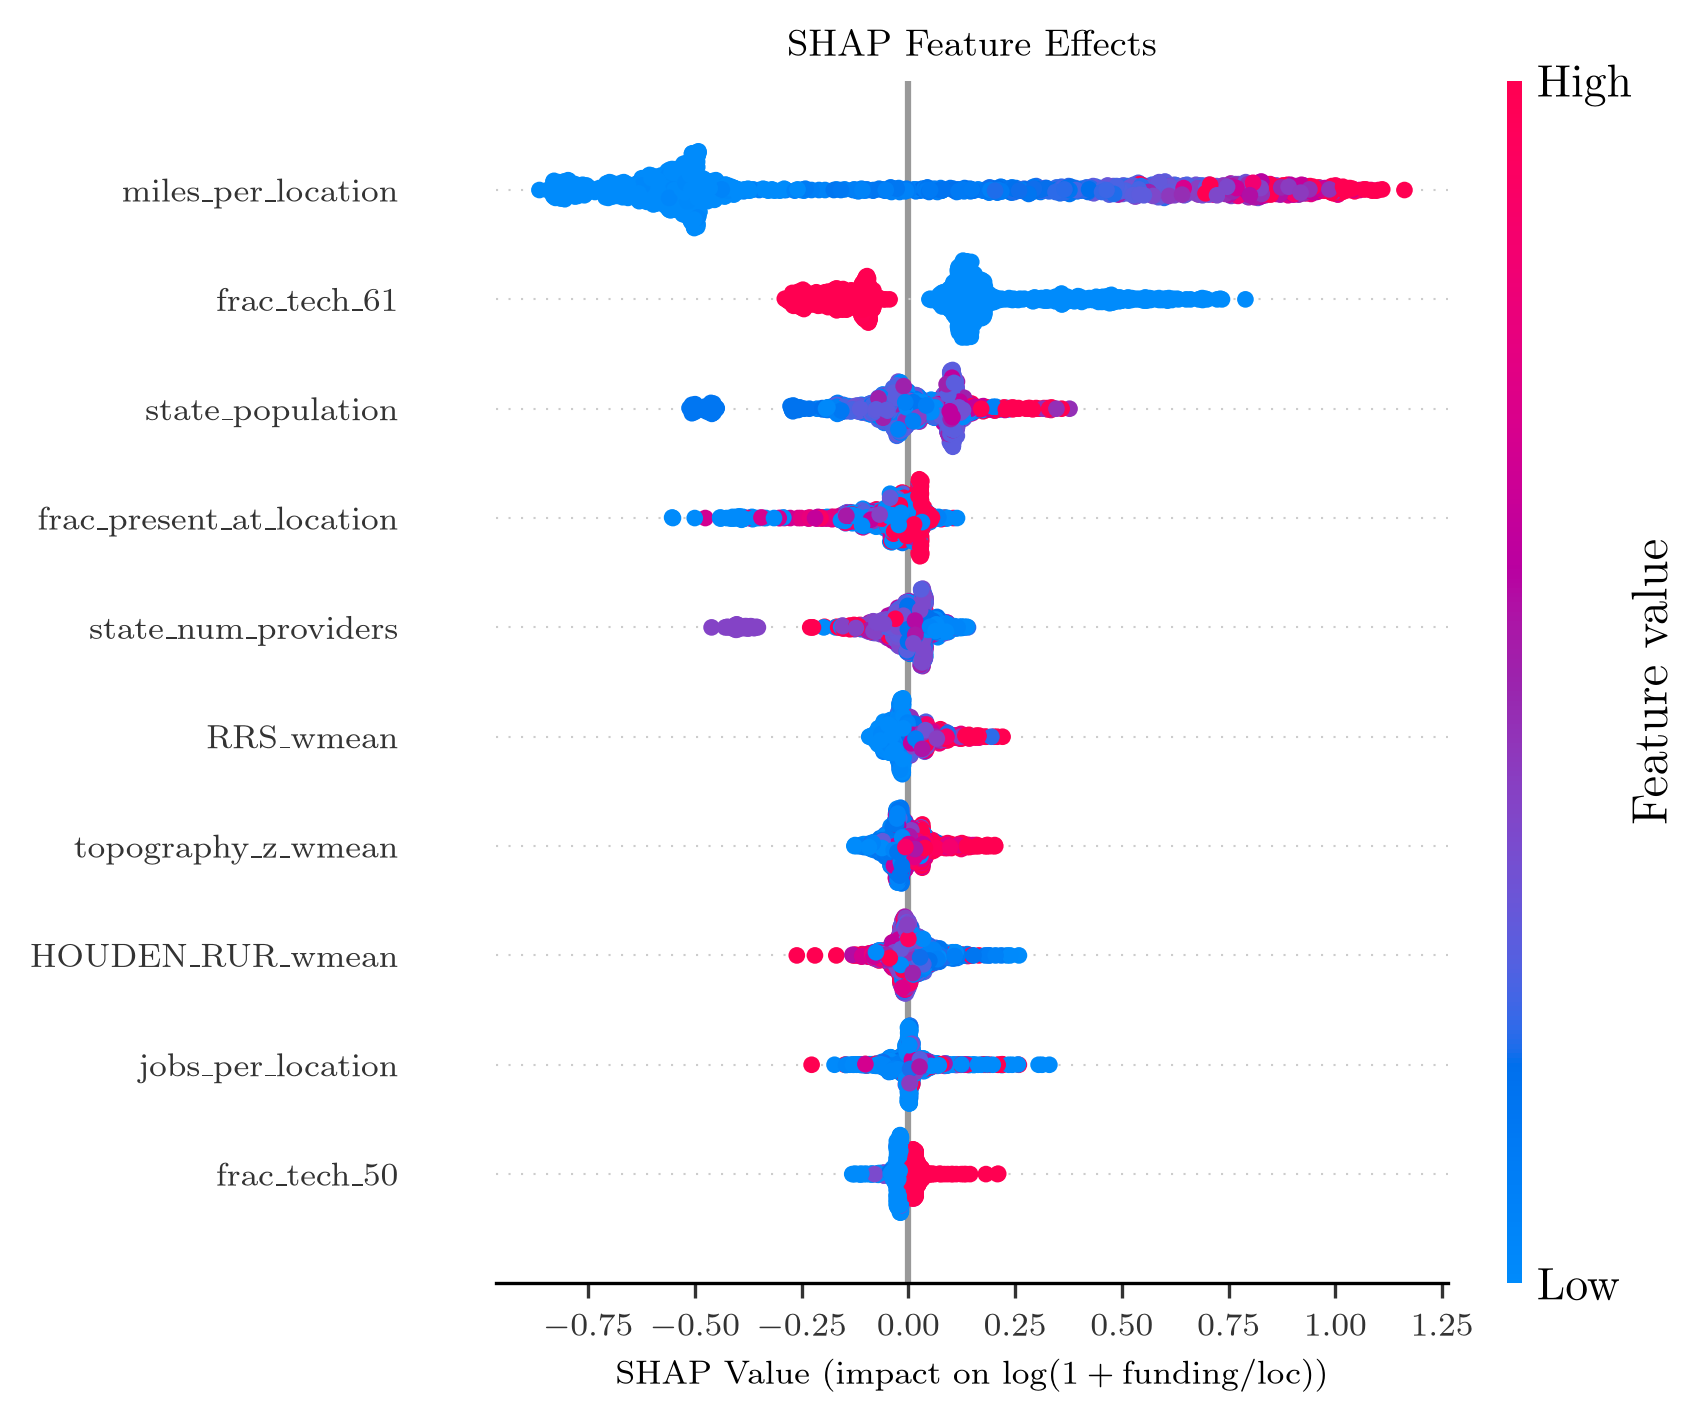

Saved: fig_shap_beeswarm.pdf / .png


In [84]:
# ============================================================
# Figure 2: SHAP Beeswarm Summary Plot
# ============================================================
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots()
shap.summary_plot(shap_values, X_test,
                  show=False, plot_size=None, max_display=10)
ax = plt.gca()
ax.set_xlabel('SHAP Value (impact on $\\log(1+\\mathrm{funding/loc})$)', fontsize=8)
ax.set_title('SHAP Feature Effects', weight='bold', fontsize=9)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)

plt.savefig('fig_shap_beeswarm.pdf')
plt.savefig('fig_shap_beeswarm.png')
plt.show()
print('Saved: fig_shap_beeswarm.pdf / .png')

In [ ]:
# Permutation importance: shuffles each feature on the TEST set and measures the R² drop
# Unlike Gini importance, measures what the model actually relies on for generalization

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf, X_test, y_test,
    scoring='r2',
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_df = (
    pd.DataFrame({
        'feature': feature_cols_full,
        'perm_mean': perm.importances_mean,
        'perm_std': perm.importances_std,
        'gini': rf.feature_importances_,
    })
    .sort_values('perm_mean', ascending=False)
    .reset_index(drop=True)
)

print(f"Permutation importance (drop in test R² when feature is shuffled)")
print(f"{'='*70}")
print(perm_df.to_string(index=False,
      formatters={'perm_mean': '{:+.4f}'.format,
                  'perm_std':  '{:.4f}'.format,
                  'gini':      '{:.4f}'.format}))

# Plot
fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(perm_df))))
order = perm_df.sort_values('perm_mean', ascending=True)
ax.barh(order['feature'], order['perm_mean'],
        xerr=order['perm_std'], color='#4878A8', ecolor='#888',
        edgecolor='white', linewidth=0.3)
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel('Permutation importance (R² drop)')
ax.set_title('Project-level RF: permutation importance on test set',
             weight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

# Flag features with essentially zero generalization value
noise_features = perm_df.loc[
    perm_df['perm_mean'] < perm_df['perm_std'], 'feature'
].tolist()
print(f"\nFeatures with |perm_mean| < perm_std (candidates to drop): "
      f"{len(noise_features)}")
for f in noise_features:
    print(f"  - {f}")